In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os

In [2]:
PROJECT_ROOT = Path("/Users/elenipapadopulos/Desktop/PhD/Logical_structure_XAI")
RESULTS_ROOT = PROJECT_ROOT / "new_results" / "distilbert-base-uncased-finetuned-sst-2-english"
METHODS      = ["Occlusion", "Shap", "LIME"]

### Set config

In [3]:
CONFIGS = [
    ("base",        "sentence_not_1",             "base n=1",        {-2: "not"}),
    ("base",        "sentence_not_2",             "base n=2",        {-3: "first not", -2: "second not"}),
    ("base",        "sentence_not_3",             "base n=3",        {-4: "first not", -3: "second not", -2: "third not"}),
    ("contraction", "sentence_not_1_contraction", "contraction n=1", {-2: "not"}),
    ("contraction", "sentence_not_2_contraction", "contraction n=2", {-3: "first not", -2: "second not"}),
    ("not_start",   "sentence_not_beginning",     "not_at",          {0: "not"}),
    #("not_start",   "sentence_not_2_beginning",   "not_at n=2",      {-3: "first not", -2: "second not"}),
    ("aux_not",     "sentence_not_0_aux",         "aux n=0",         {2: "aux not"}),
    ("aux_not",     "sentence_not_1_aux",         "aux n=1",         {2: "aux not", -2: "adj not"}),
    #("aux_not",     "sentence_not_2_aux",         "aux n=2",         {2: "aux not", -3: "first adj not", -2: "second adj not"}),
]

PALETTE = ["#e94560", "#0f9b8e", "#f5a623", "#7b68ee", "#50fa7b", "#ff79c6"]

plt.rcParams.update({
    "font.family": "Arial",                
    "font.size": 16,                       
    "axes.titlesize": 18,                  
    "axes.labelsize": 16,                  
    "xtick.labelsize": 10,                  
    "ytick.labelsize": 10,                  
    "legend.fontsize": 10,                  
    "figure.titlesize": 14,                
    "lines.linewidth": 1.5,                
    "lines.markersize": 5,                 
    "savefig.dpi": 300,                    
    "savefig.bbox": "tight",               
    "figure.autolayout": True,             
    "axes.grid": False,                    
    "axes.linewidth": 0.8,                 
    "text.usetex": False,                   
})

### Utils

In [14]:
# def plot_not_attribution(model_name):
#     results_root = PROJECT_ROOT / "results" / model_name

#     for folder, filename, label, positions in CONFIGS:
#         fig, axes = plt.subplots(1, 3, figsize=(18, 5))
#         fig.suptitle(f"'not' attribution  —  {label}  —  {model_name}",
#                      fontweight="bold", color="black", y=1.02)

#         for ax, method in zip(axes, METHODS):
#             ax.set_title(method, fontweight="bold", pad=10)
#             ax.set_xlabel("Feature importance")
#             ax.set_ylabel("Density")
#             ax.spines["top"].set_visible(False)
#             ax.spines["right"].set_visible(False)

#             path = results_root / method / folder / f"{filename}.pkl"
#             if not path.exists():
#                 print(f"Missing: {path}")
#                 continue

#             with open(path, "rb") as f:
#                 distrib = pickle.load(f)

#             for j, (pos, pos_label) in enumerate(positions.items()):
#                 scores = [arr[pos] for arr in distrib]
#                 sns.kdeplot(scores, ax=ax, cut=0, fill=True, alpha=0.2,
#                             color=PALETTE[j], linestyle="--", linewidth=2, label=pos_label)

#             ax.legend()
#             ax.set_xlim(0, 1)

#         plt.tight_layout()
#         os.makedirs(f"plots/{model_name}", exist_ok=True)
#         plt.savefig(f"plots/{model_name}/{label.replace(' ', '_')}.png", facecolor="white")
#         plt.show()

# MODELS = {"siebert": "siebert/sentiment-roberta-large-english", "distilbert": "distilbert-base-uncased-finetuned-sst-2-english", "roberta": "roberta-large-sst2"}

In [15]:
def plot_not_attribution_normalized(model_name):
    results_root = PROJECT_ROOT / "new_results" / model_name

    for folder, filename, label, positions in CONFIGS:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        fig.suptitle(f"'not' attribution  —  {label}  —  {model_name}",
                     fontweight="bold", color="black", y=1.02)

        for ax, method in zip(axes, METHODS):
            ax.set_title(method, fontweight="bold", pad=10)
            ax.set_xlabel("Feature importance")
            ax.set_ylabel("Density")
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)

            path = results_root / method / folder / f"{filename}.pkl"
            if not path.exists():
                print(f"Missing: {path}")
                continue

            with open(path, "rb") as f:
                distrib = pickle.load(f)

            x = np.linspace(0, 1, 2000)
            for j, (pos, pos_label) in enumerate(positions.items()):
                scores = [arr[pos] for arr in distrib]
                kde    = gaussian_kde(scores)
                p      = kde(x)
                p     /= np.trapz(p, x)
                ax.plot(x, p, color=PALETTE[j], linestyle="--", linewidth=2, label=pos_label)
                ax.fill_between(x, p, alpha=0.2, color=PALETTE[j])

            ax.legend()
            ax.set_xlim(0, 1)

        plt.tight_layout()
        os.makedirs(f"plots/normalized/{model_name}", exist_ok=True)
        plt.savefig(f"plots/normalized/{model_name}/{label.replace(' ', '_')}.png", facecolor="white")
        plt.show()


MODELS = {"siebert": "siebert/sentiment-roberta-large-english", "distilbert": "distilbert-base-uncased-finetuned-sst-2-english", "roberta": "roberta-large-sst2"}

In [7]:
from scipy.stats import gaussian_kde
import pandas as pd

def compute_l1_distance(data1,data2,total_variation=False):
    """
    Given two arrays, infer the distribution with Gaussian KDE and compute the L1 distance between them.
    """
    kde_1 = gaussian_kde(data1)
    kde_2 = gaussian_kde(data2)
    x = np.linspace(0, 1, 2000)
    p = kde_1(x)
    q = kde_2(x)
    p /= np.trapz(p, x)
    q /= np.trapz(q, x)
    l1 = np.trapz(np.abs(p - q), x)

    if total_variation:
        return 0.5 * l1

    return l1

def k_metric(data1, data2):
    if np.allclose(data1, data1[0]) or np.allclose(data2, data2[0]): # if no variability then we set 0, KDE cannot be computed
        return 0.0
    kde1 = gaussian_kde(data1)
    kde2 = gaussian_kde(data2)
    x = np.linspace(0, 1, 2000)
    p = kde1(x)
    q = kde2(x)
    p /= np.trapz(p, x)
    q /= np.trapz(q, x)
    dissimilarity = 1 - np.trapz(np.minimum(p, q), x) / np.trapz(np.maximum(p, q), x)
    return dissimilarity

def kl_divergence(data1, data2, eps=1e-10):
    """
    Given two arrays, infer the distribution with Gaussian KDE and compute the KL divergence between them.
    """
    kde1 = gaussian_kde(data1)
    kde2 = gaussian_kde(data2)
    x = np.linspace(0, 1, 2000)
    p = kde1(x)
    q = kde2(x)
    p /= np.trapz(p, x)
    q /= np.trapz(q, x)
    p = np.clip(p, eps, None)
    q = np.clip(q, eps, None)
    kl = np.trapz(p * np.log(p / q), x)

    return kl


In [8]:
from scipy.stats import gaussian_kde
from itertools import combinations


CROSS_CONFIGS = [
    ("base n=1", -2, "contraction n=1", -2),
    ("base n=1", -2, "not_at",      -2),
    ("base n=1", -2, "aux n=1",         -2),
    ("contraction n=1", -2, "not_at", -2),
    ("contraction n=1", -2, "aux n=1",    -2),
]

def compute_metrics_between_nots(model_name):
    results_root = PROJECT_ROOT / "results" / model_name
    records = []

    # helper to load scores for a config
    def load_scores(folder, filename, pos):
        path = results_root / method / folder / f"{filename}.pkl"
        if not path.exists():
            return None
        with open(path, "rb") as f:
            distrib = pickle.load(f)
        return [arr[pos] for arr in distrib]

    # build a lookup: label -> (folder, filename, positions)
    config_lookup = {label: (folder, filename, positions)
                     for folder, filename, label, positions in CONFIGS}
    
    print(list(config_lookup.keys()))       
    

    for method in METHODS:

        # ── within-config: compare multiple nots ──────────────────────────
        for folder, filename, label, positions in CONFIGS:
            if len(positions) < 2:
                continue

            scores_per_pos = {}
            for pos, pos_label in positions.items():
                s = load_scores(folder, filename, pos)
                if s is not None:
                    scores_per_pos[pos_label] = s

            for a, b in combinations(list(scores_per_pos.keys()), 2):
                data1, data2 = scores_per_pos[a], scores_per_pos[b]
                records.append({
                    "comparison": "within_config",
                    "config_a":   label,
                    "config_b":   label,
                    "pair":       f"{a} vs {b}",
                    "method":     method,
                    "L1":         compute_l1_distance(data1, data2),
                    "K":          k_metric(data1, data2),
                    "KL":         kl_divergence(data1, data2),
                })

        # ── cross-config: compare same "not" position across configs ──────
        for label_a, pos_a, label_b, pos_b in CROSS_CONFIGS:
            # if label_a not in config_lookup or label_b not in config_lookup:
            #     continue
            folder_a, filename_a, _ = config_lookup[label_a]
            folder_b, filename_b, _ = config_lookup[label_b]

            data1 = load_scores(folder_a, filename_a, pos_a)
            data2 = load_scores(folder_b, filename_b, pos_b)

            if data1 is None or data2 is None:
                continue

            records.append({
                "comparison": "cross_config",
                "config_a":   label_a,
                "config_b":   label_b,
                "pair":       f"pos {pos_a} vs pos {pos_b}",
                "method":     method,
                "L1":         compute_l1_distance(data1, data2),
                "K":          k_metric(data1, data2),
                "KL":         kl_divergence(data1, data2),
            })

    df = pd.DataFrame(records).sort_values("method").reset_index(drop=True)
    os.makedirs("results", exist_ok=True)
    df.to_csv(f"results/{model_name}/metrics_between_nots.csv", index=False)
    return df

## SIEBERT

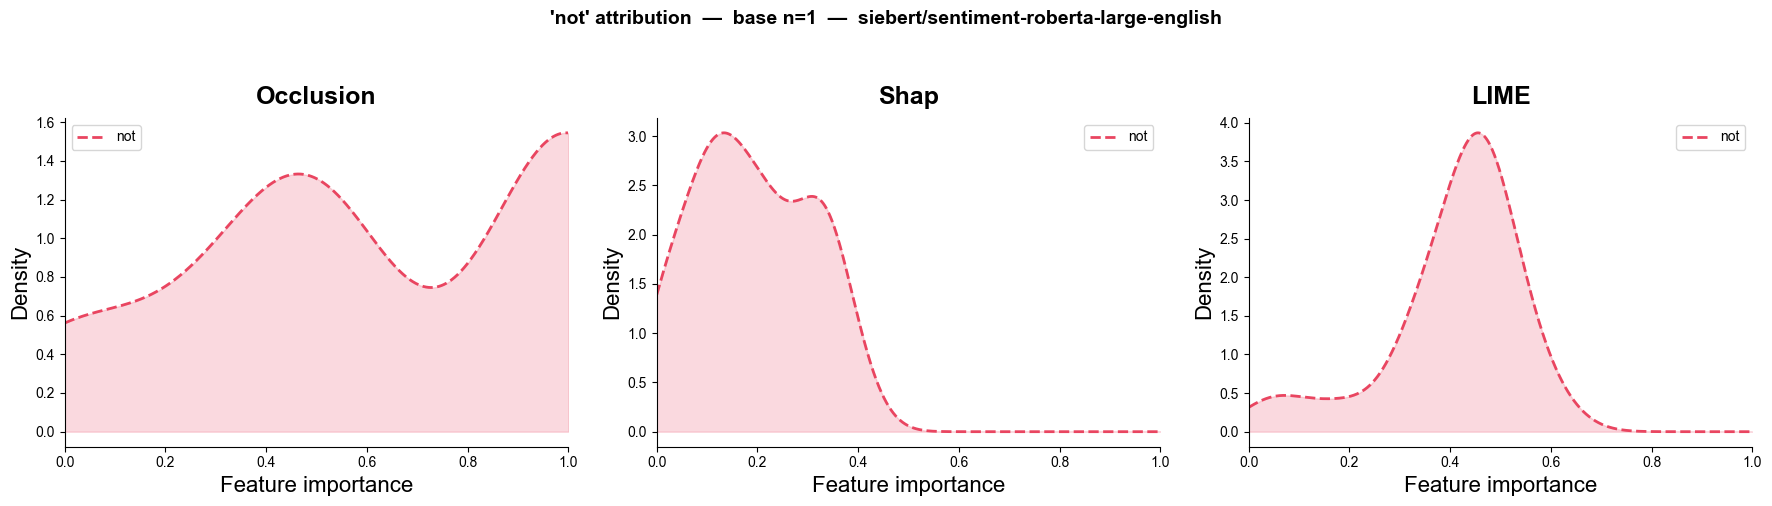

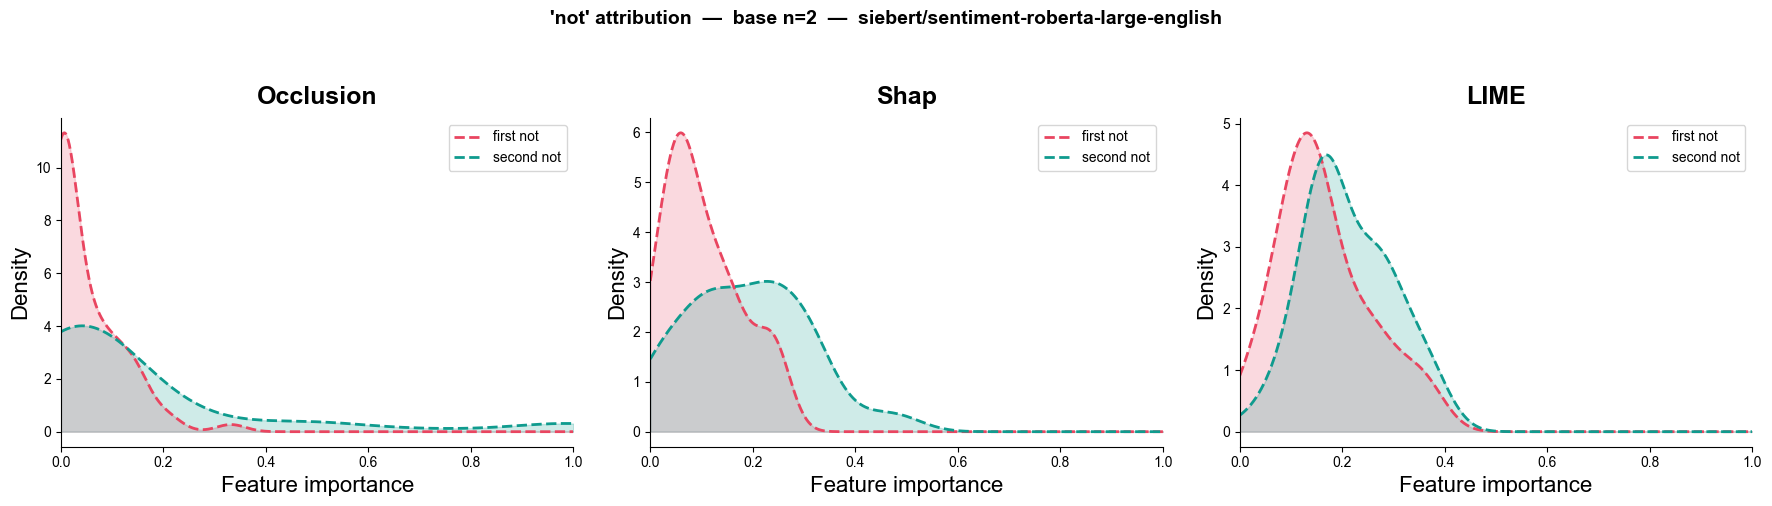

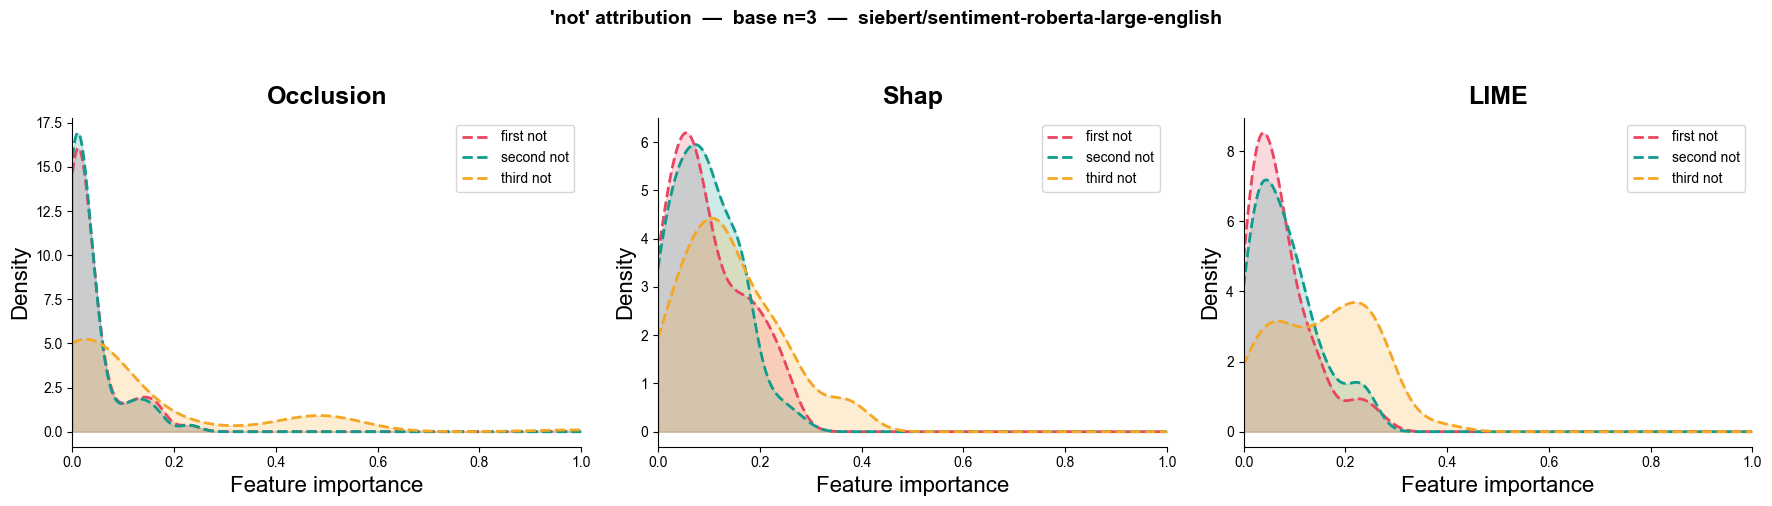

Missing: /Users/elenipapadopulos/Desktop/PhD/Logical_structure_XAI/new_results/siebert/sentiment-roberta-large-english/LIME/contraction/sentence_not_1_contraction.pkl


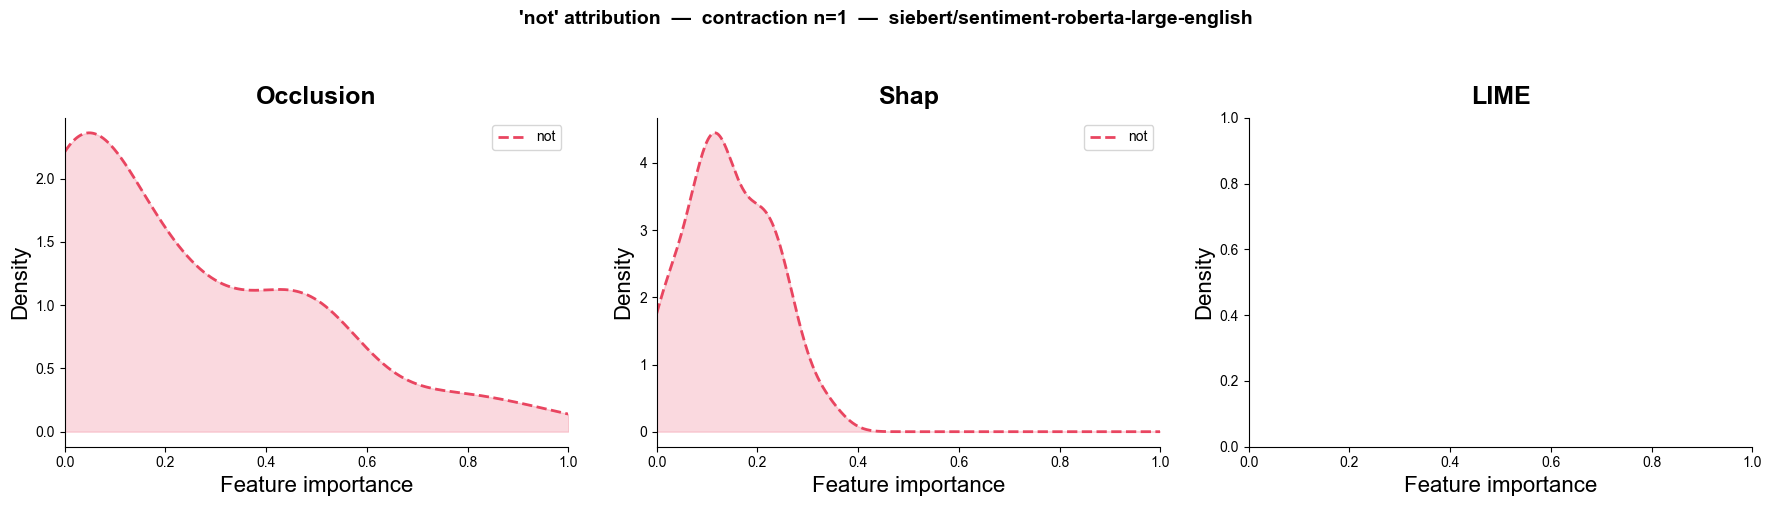

Missing: /Users/elenipapadopulos/Desktop/PhD/Logical_structure_XAI/new_results/siebert/sentiment-roberta-large-english/LIME/contraction/sentence_not_2_contraction.pkl


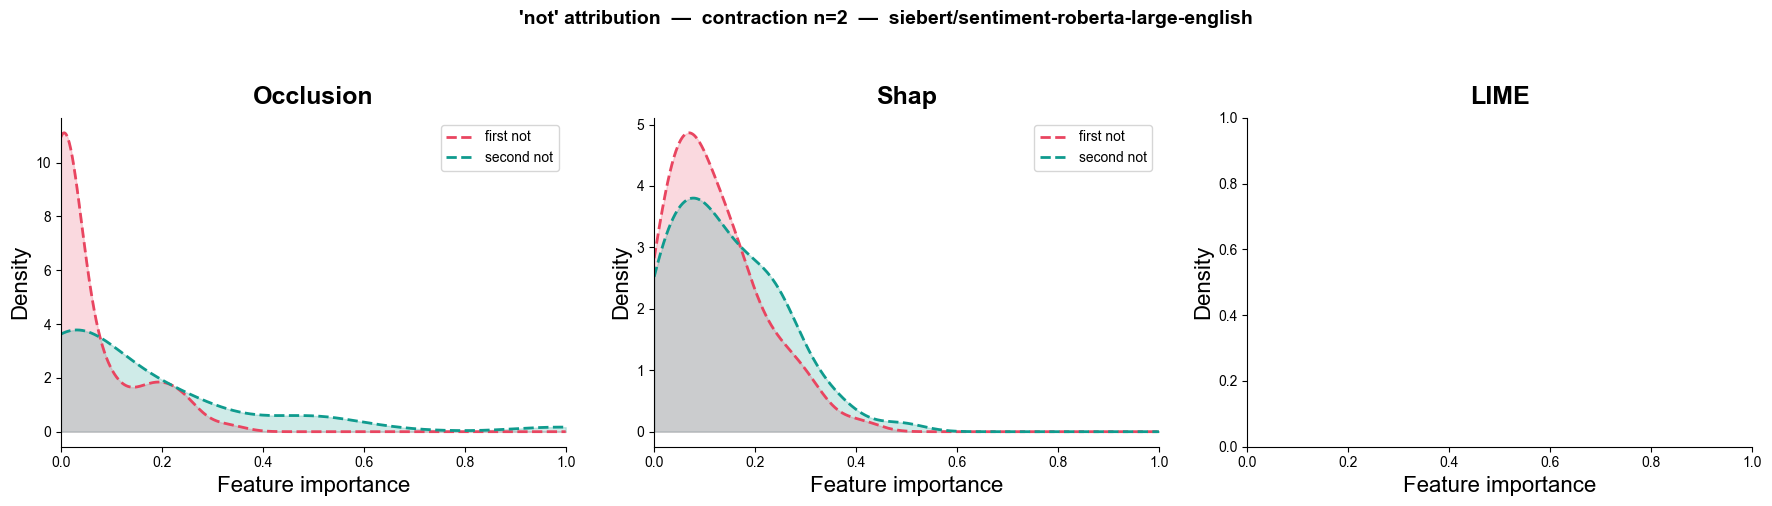

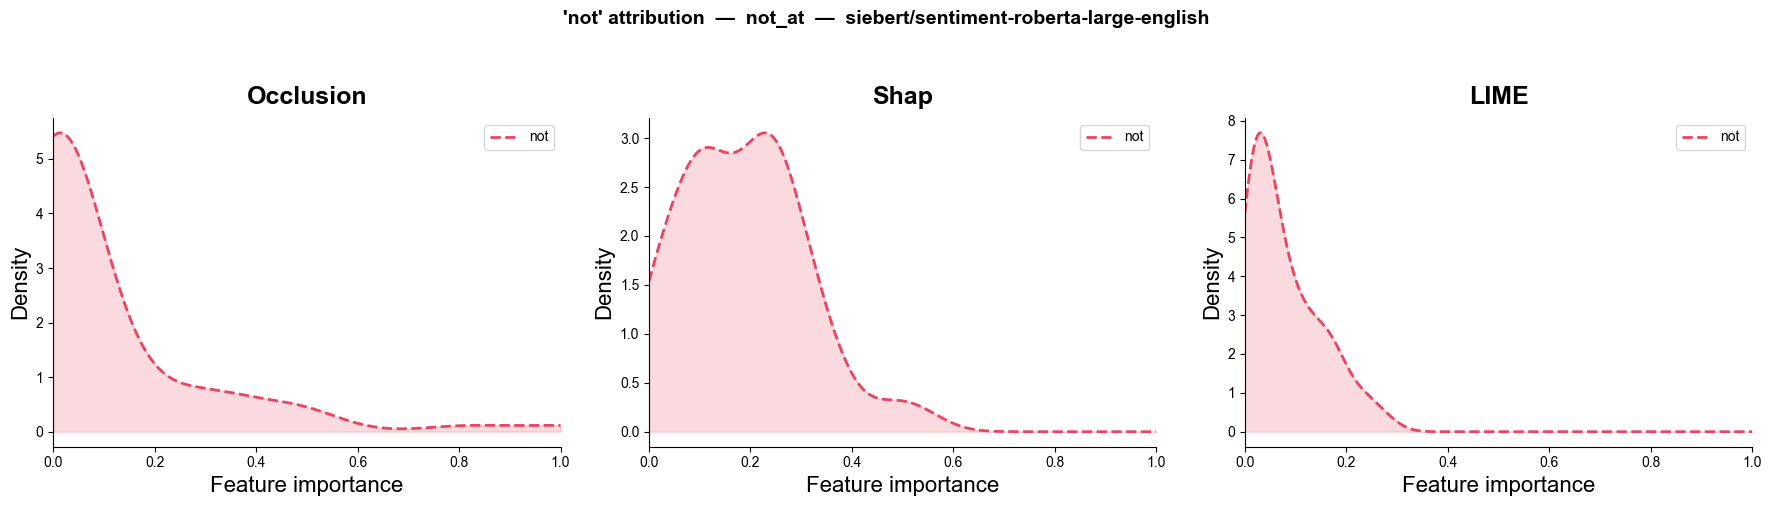

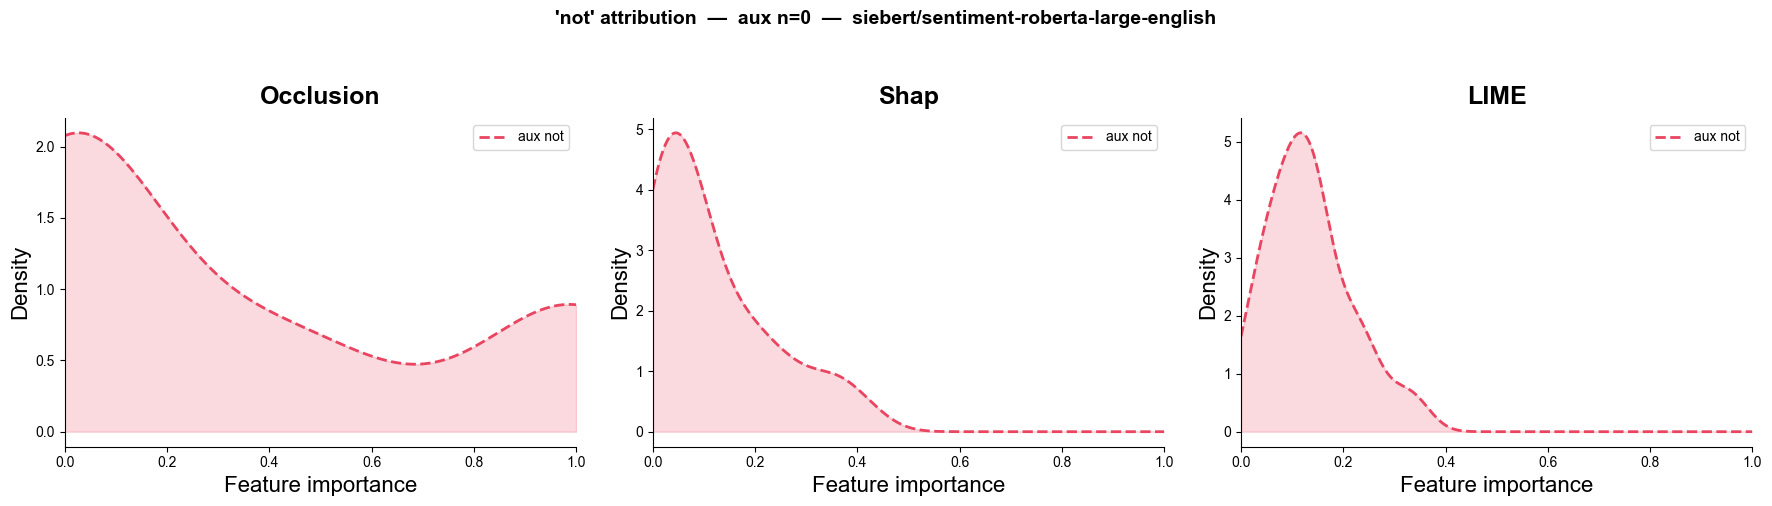

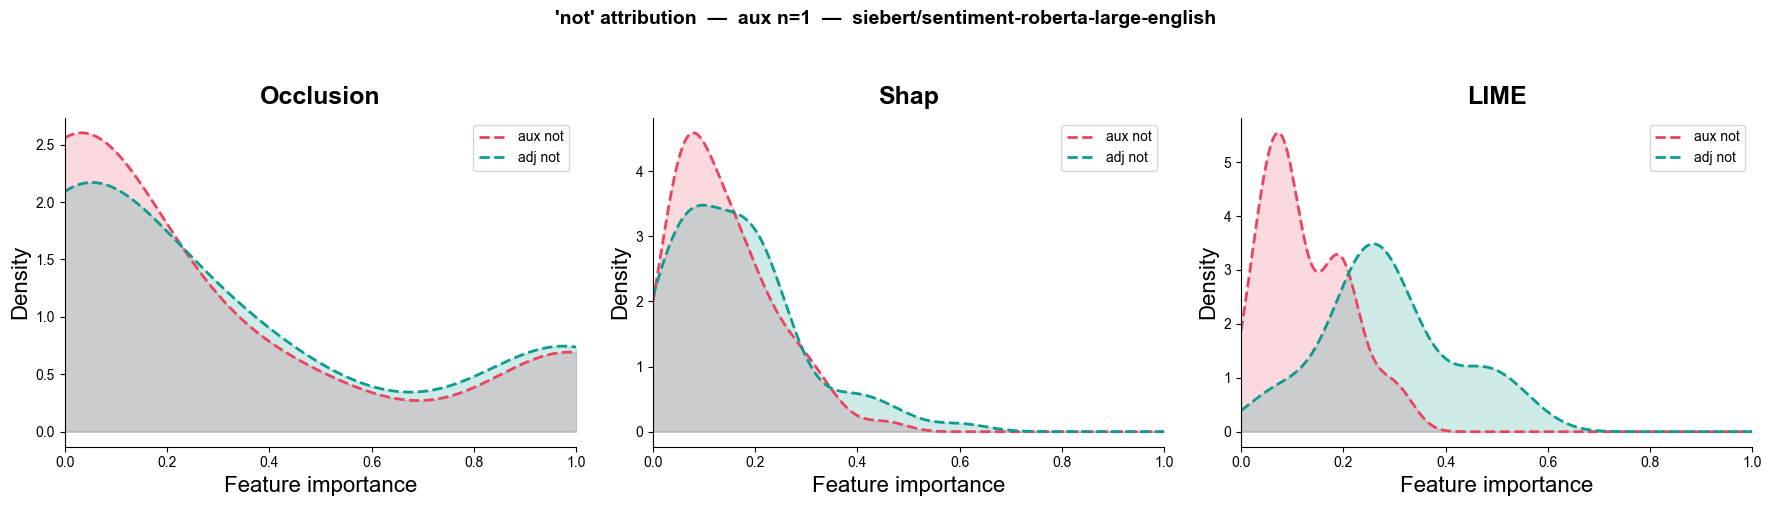

In [19]:
plot_not_attribution_normalized(MODELS["siebert"])

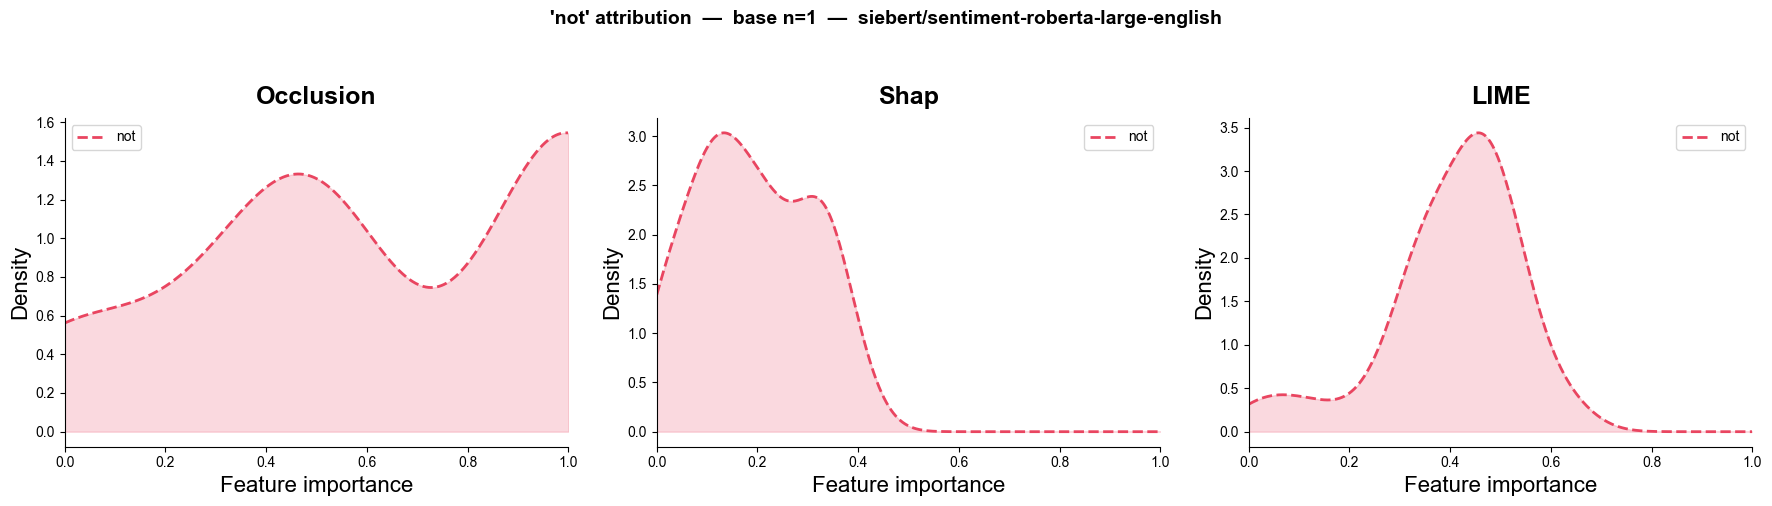

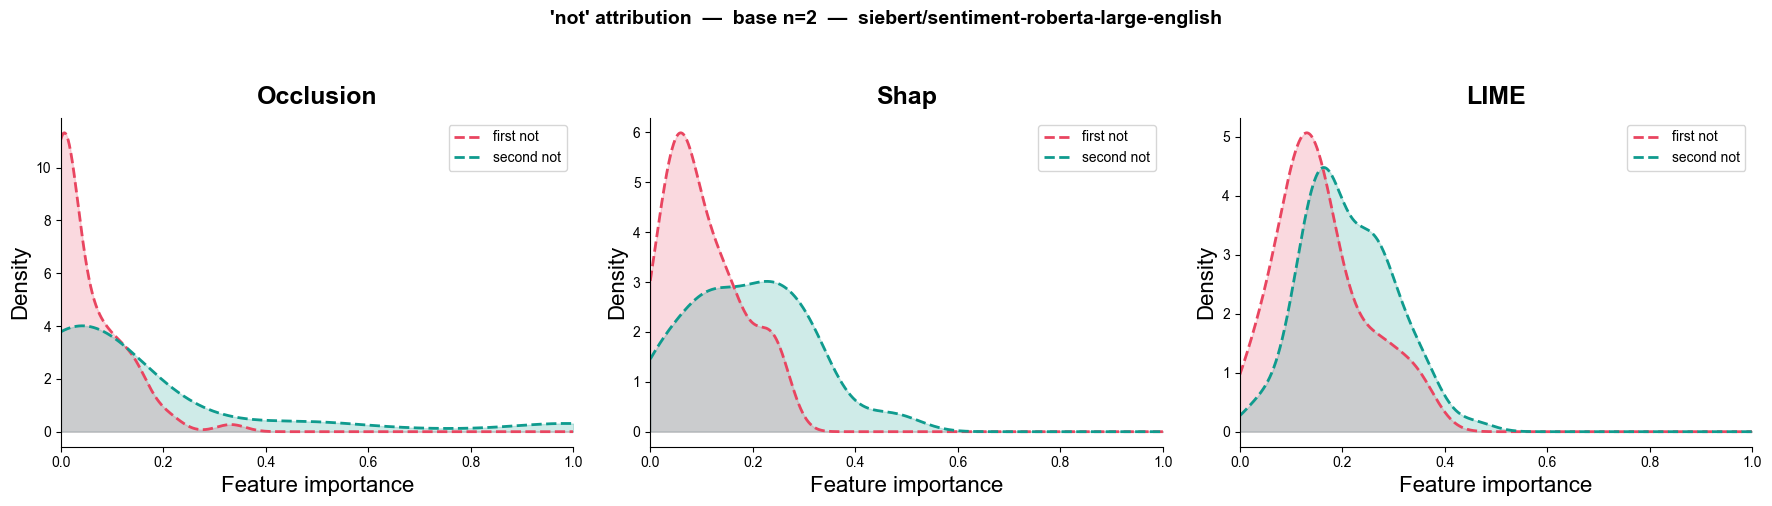

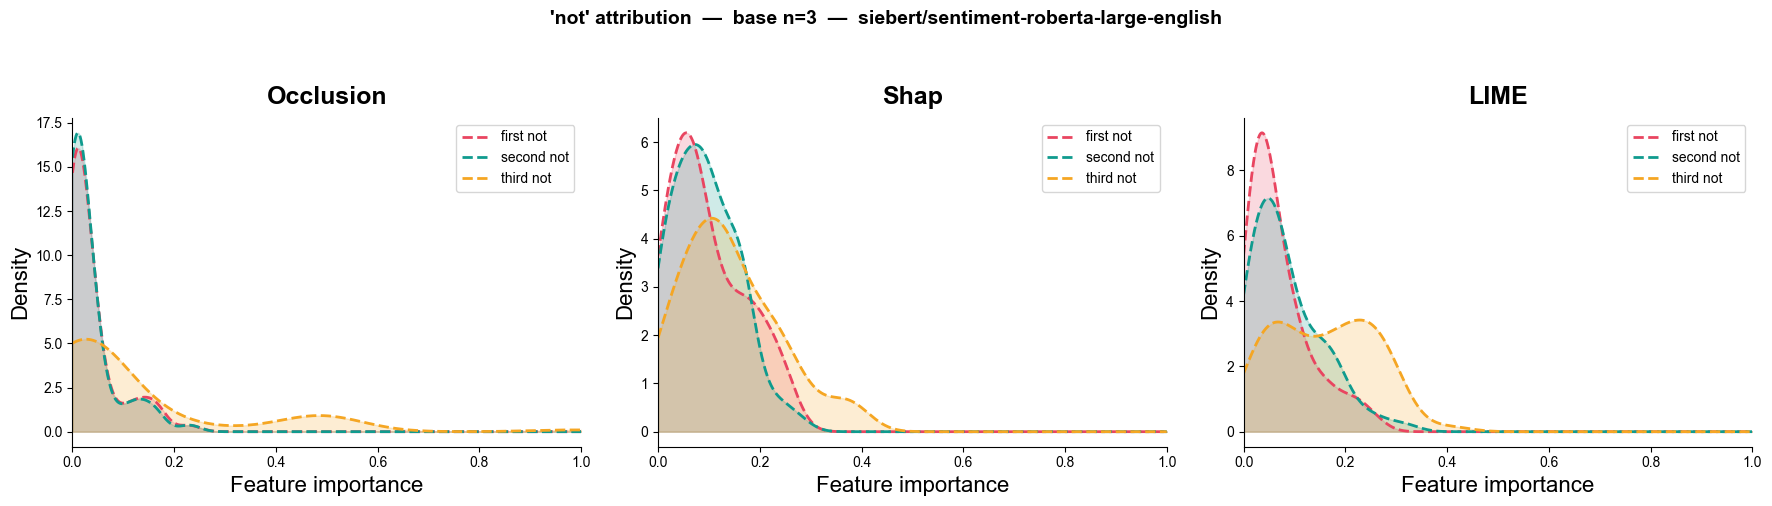

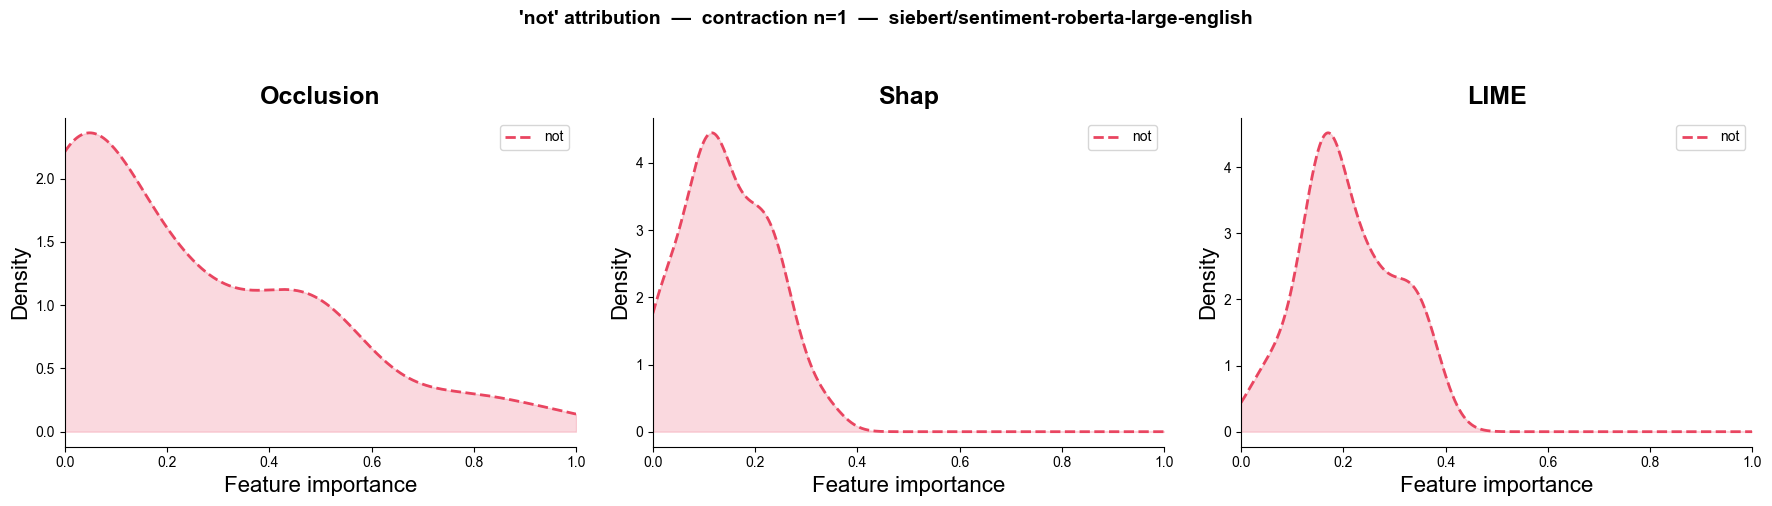

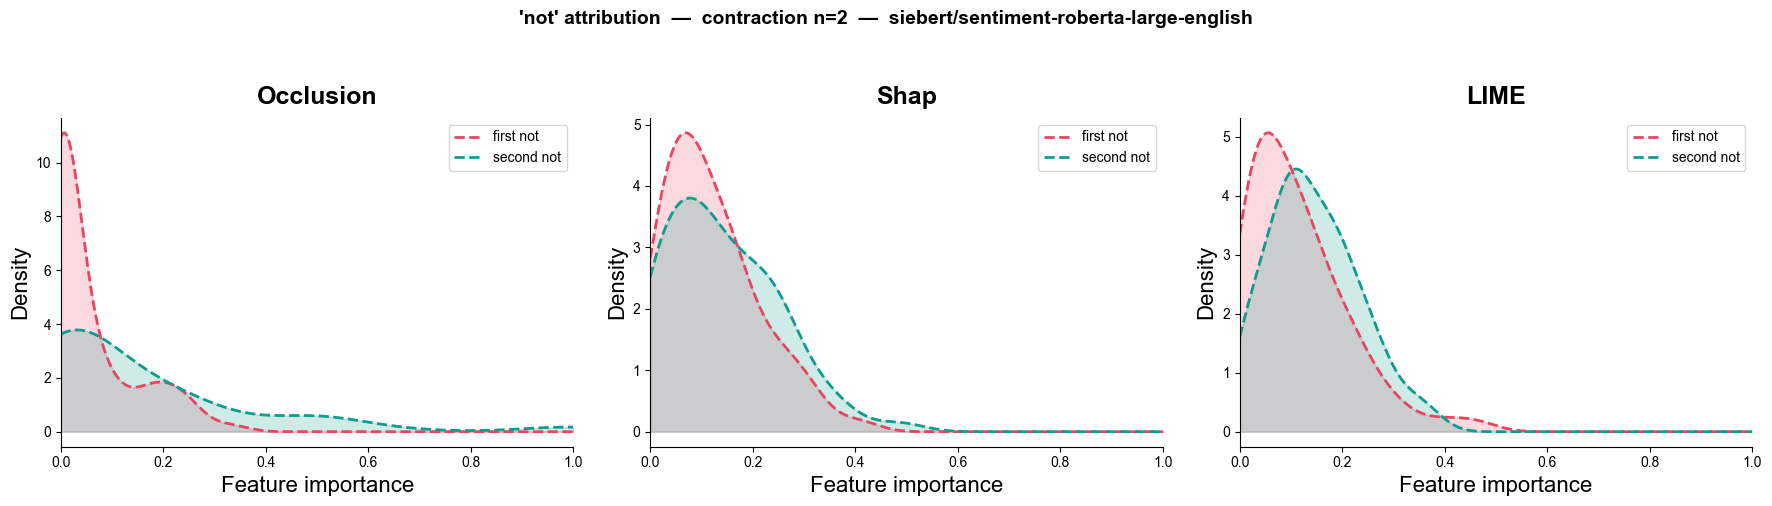

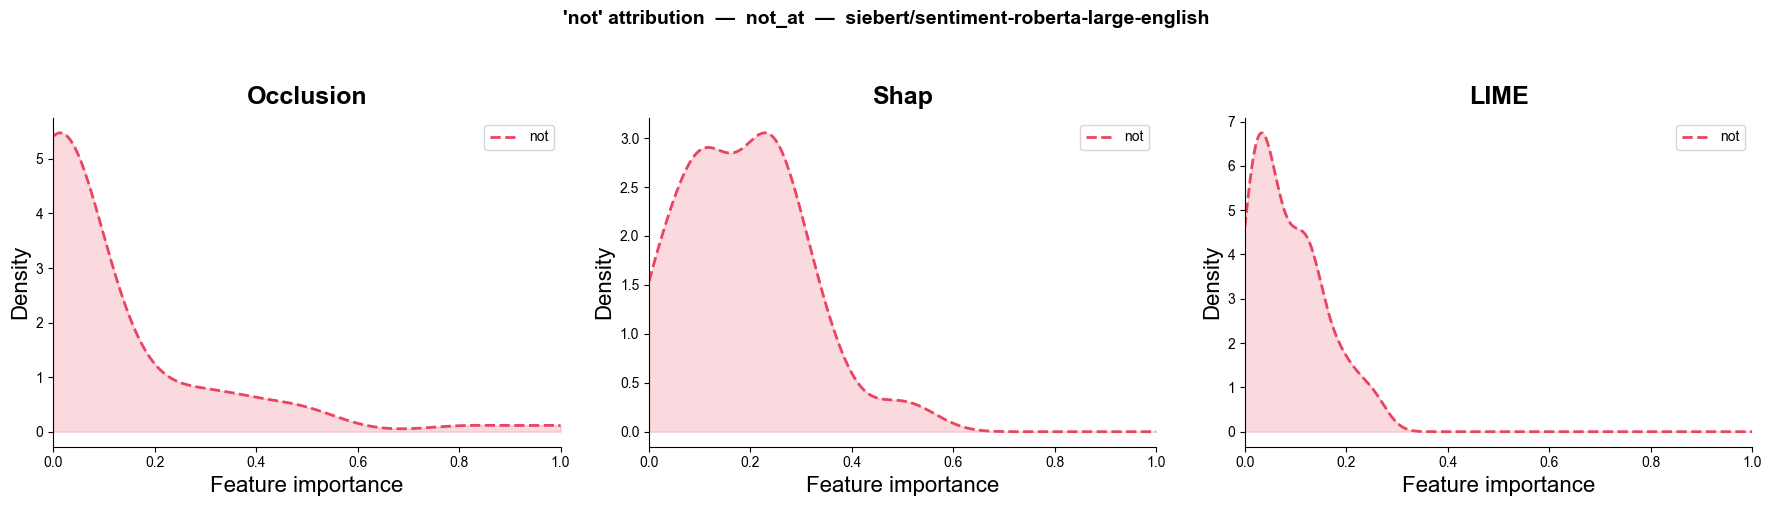

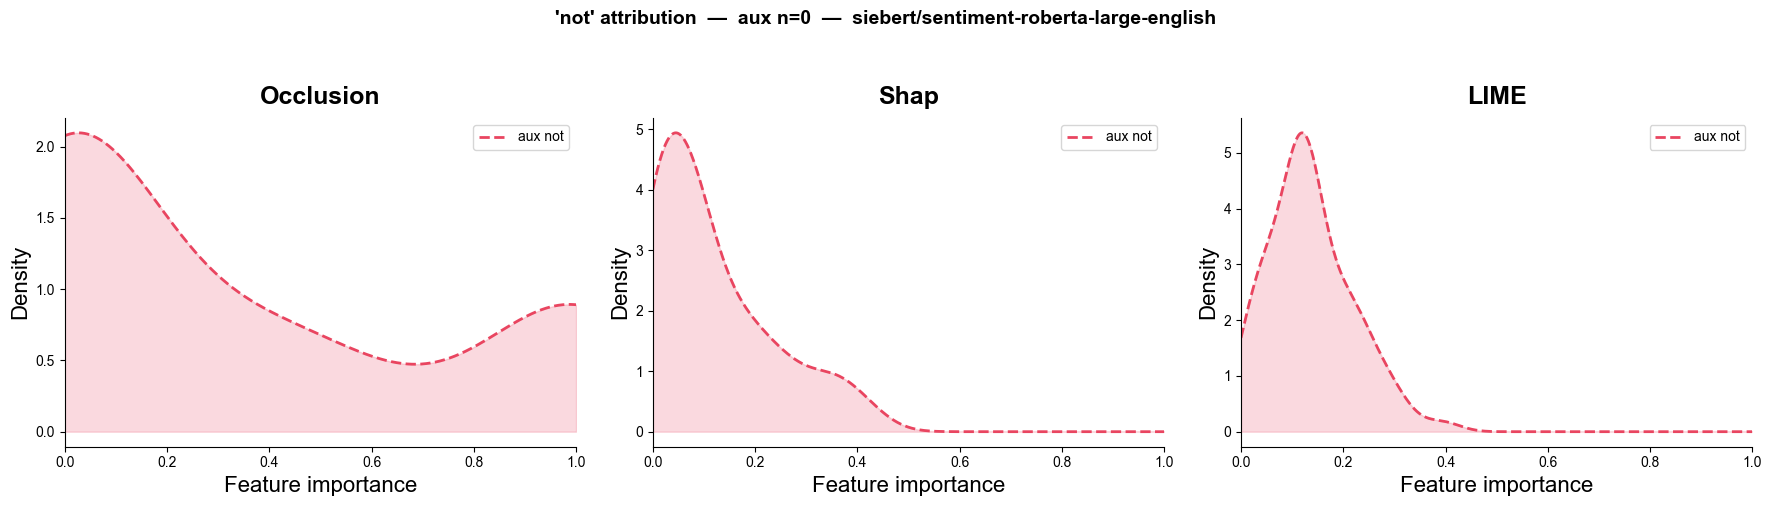

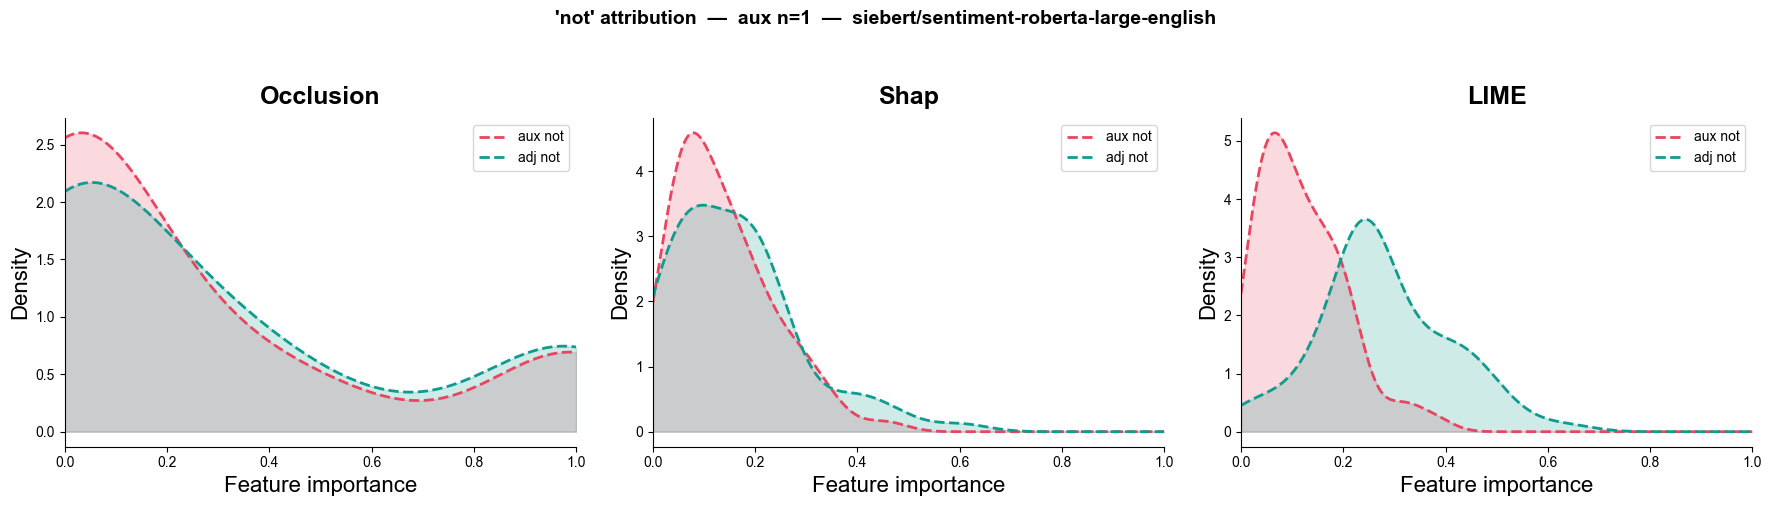

In [10]:
plot_not_attribution_normalized(MODELS["roberta"])

## DistilBERT

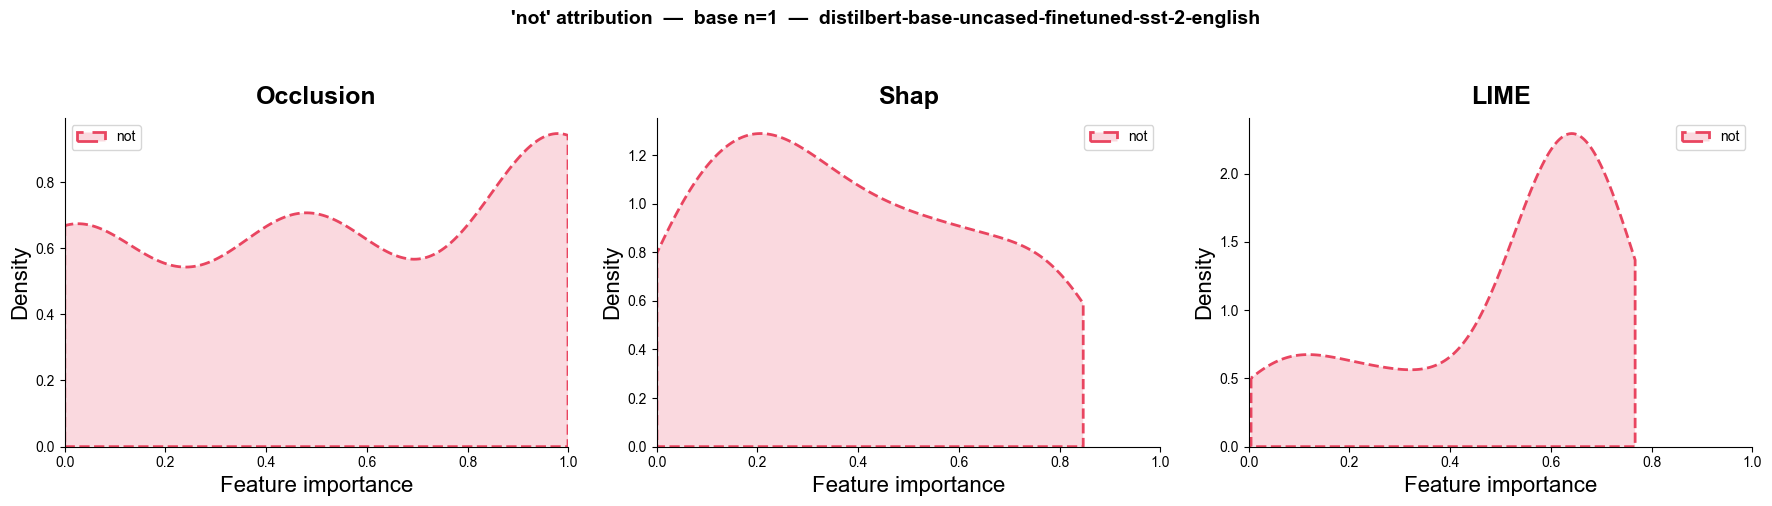

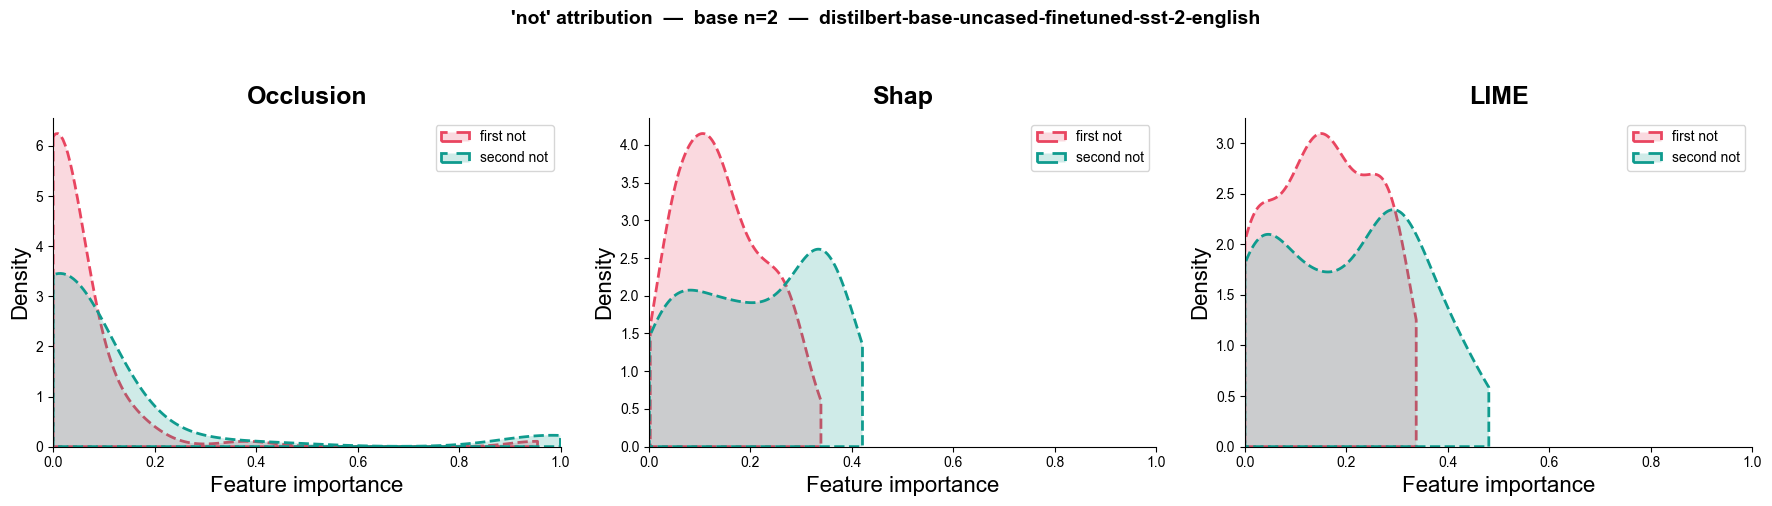

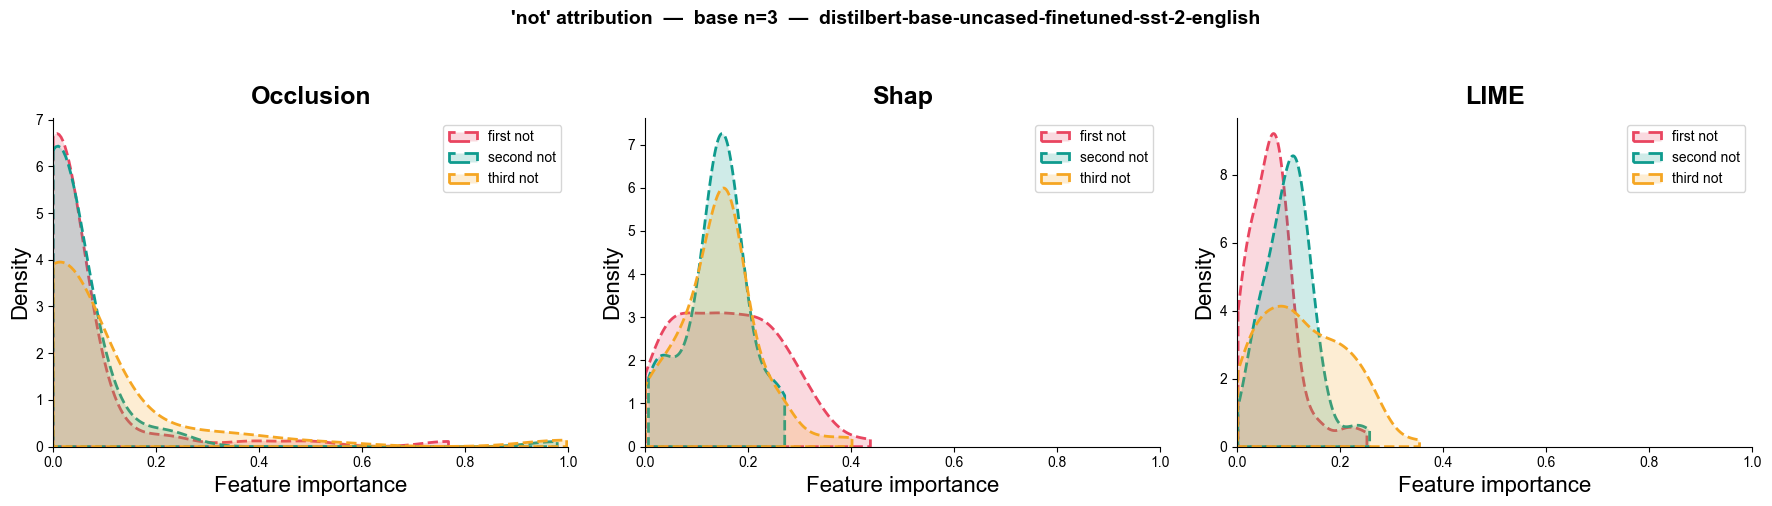

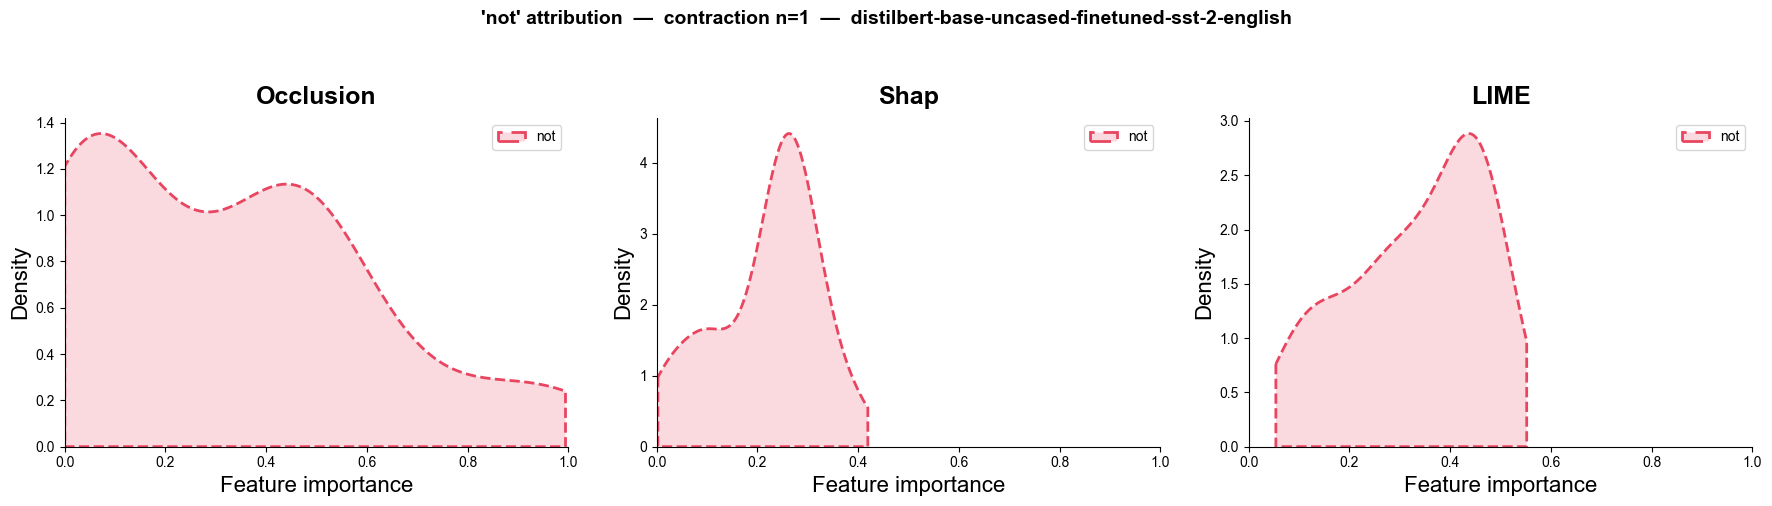

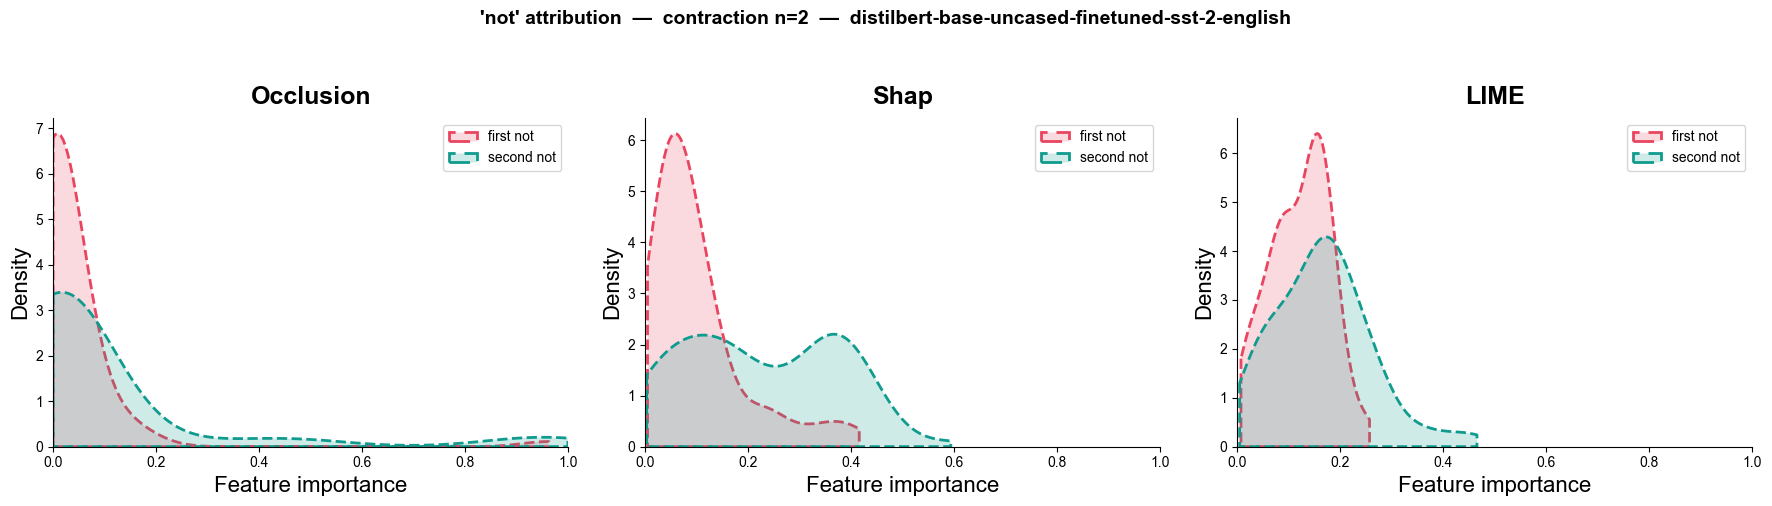

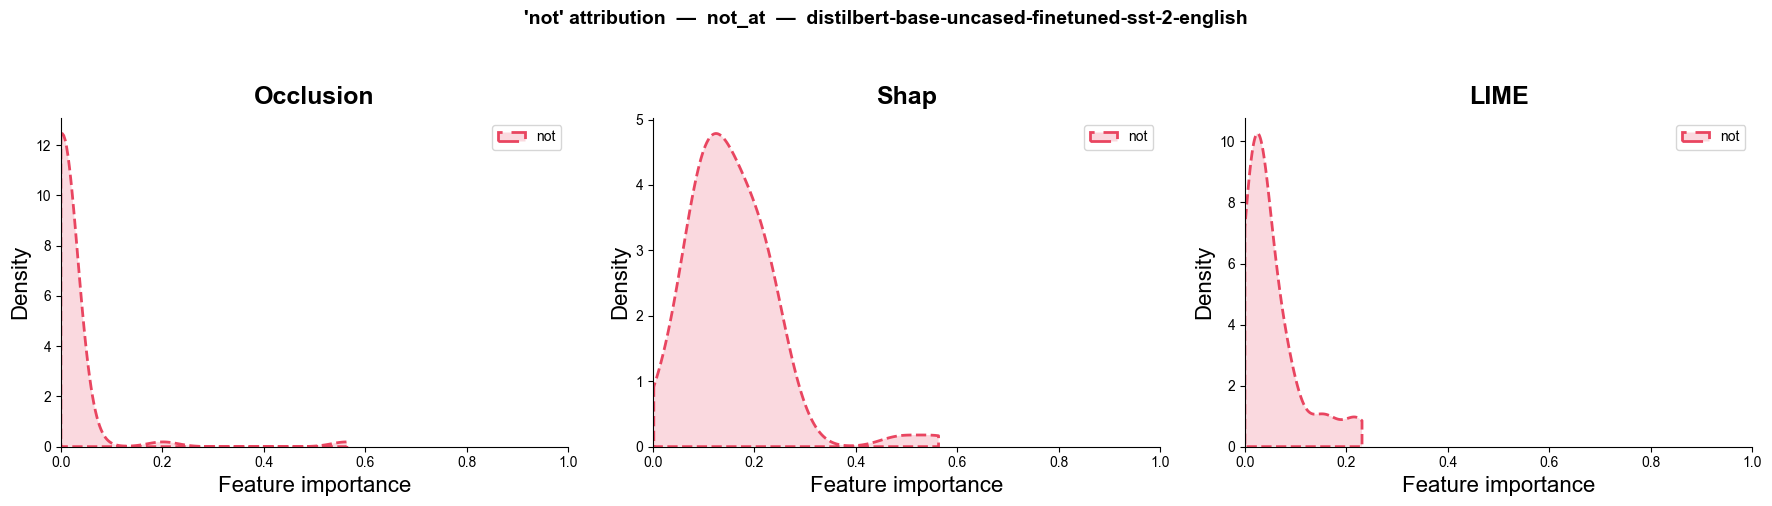

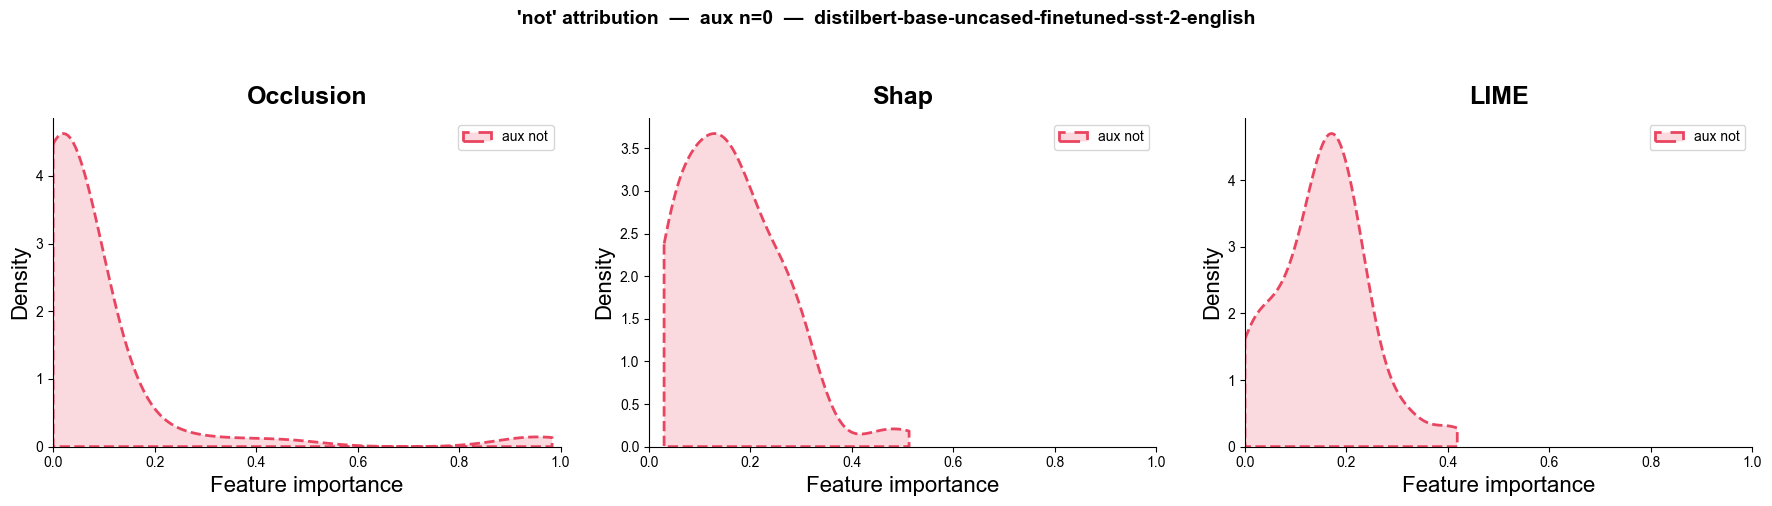

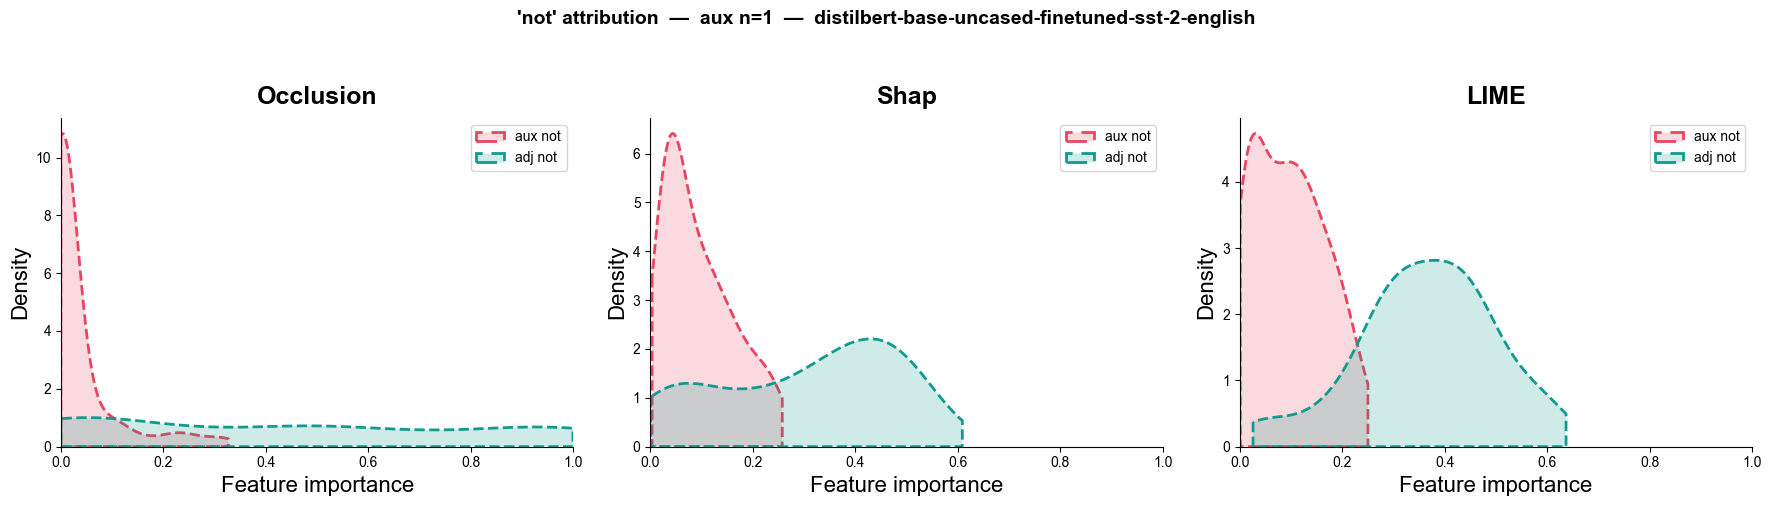

In [10]:
plot_not_attribution(MODELS["distilbert"])

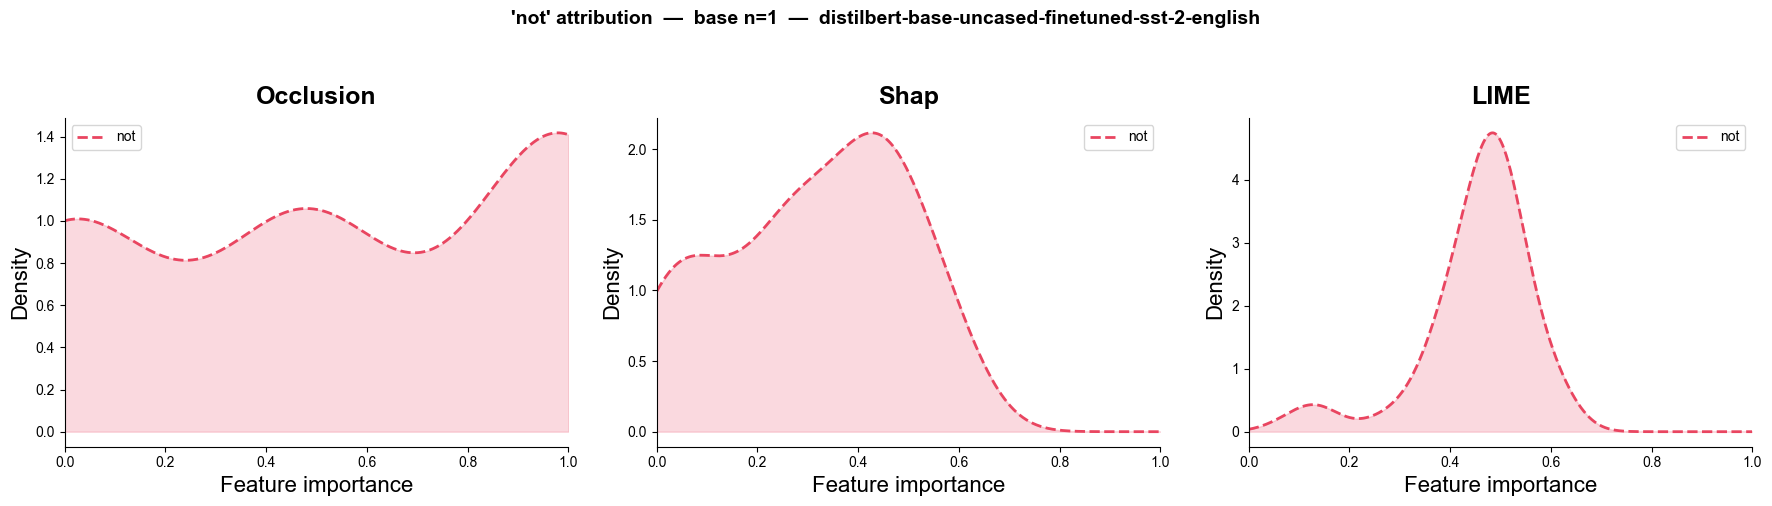

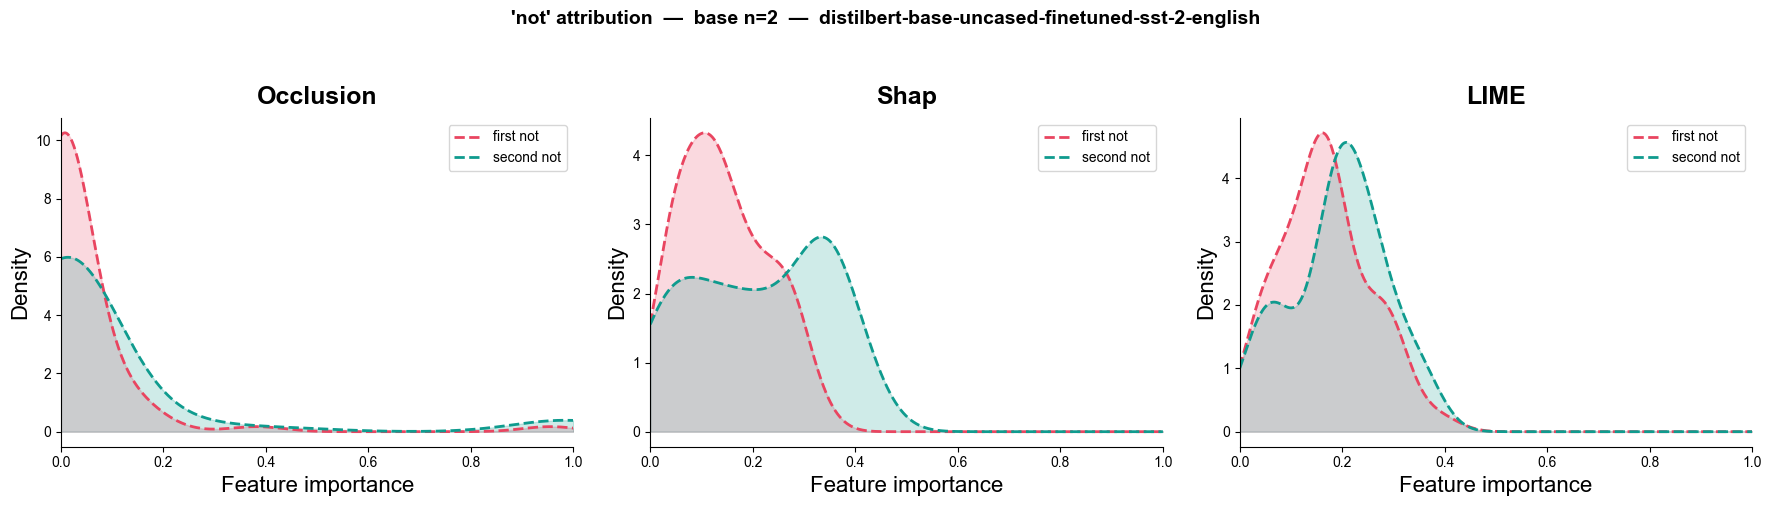

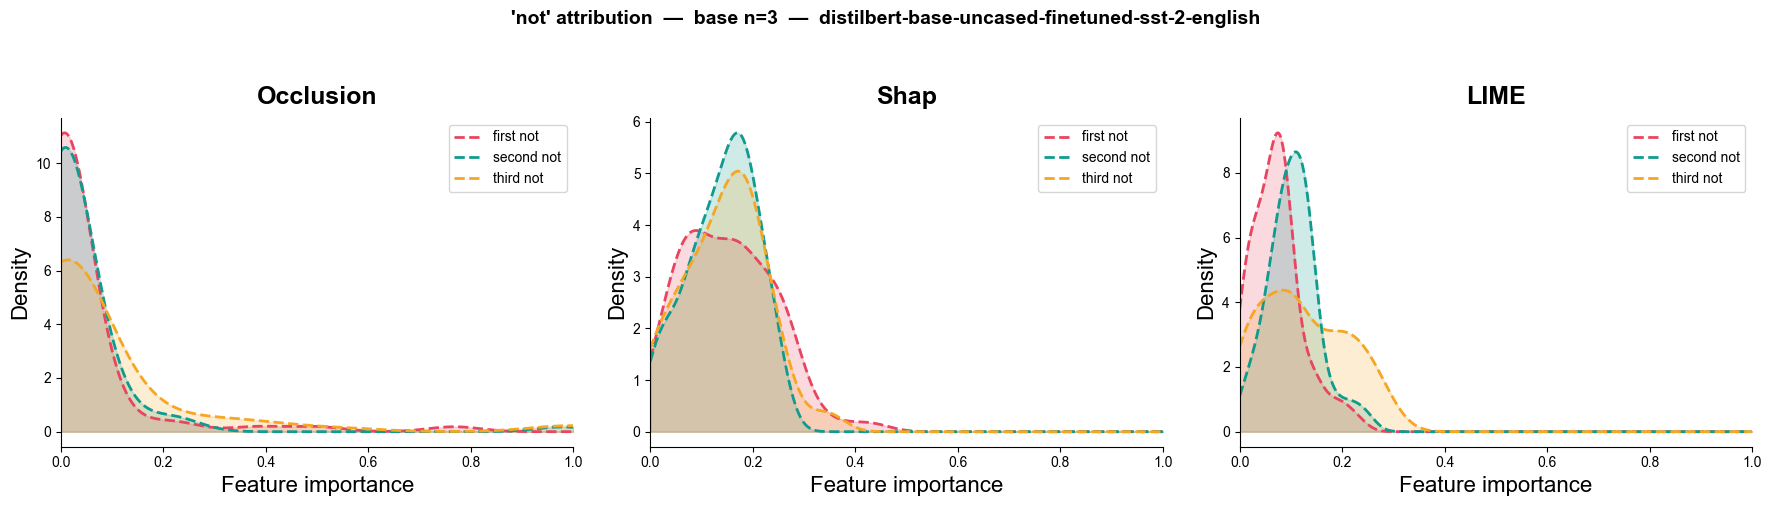

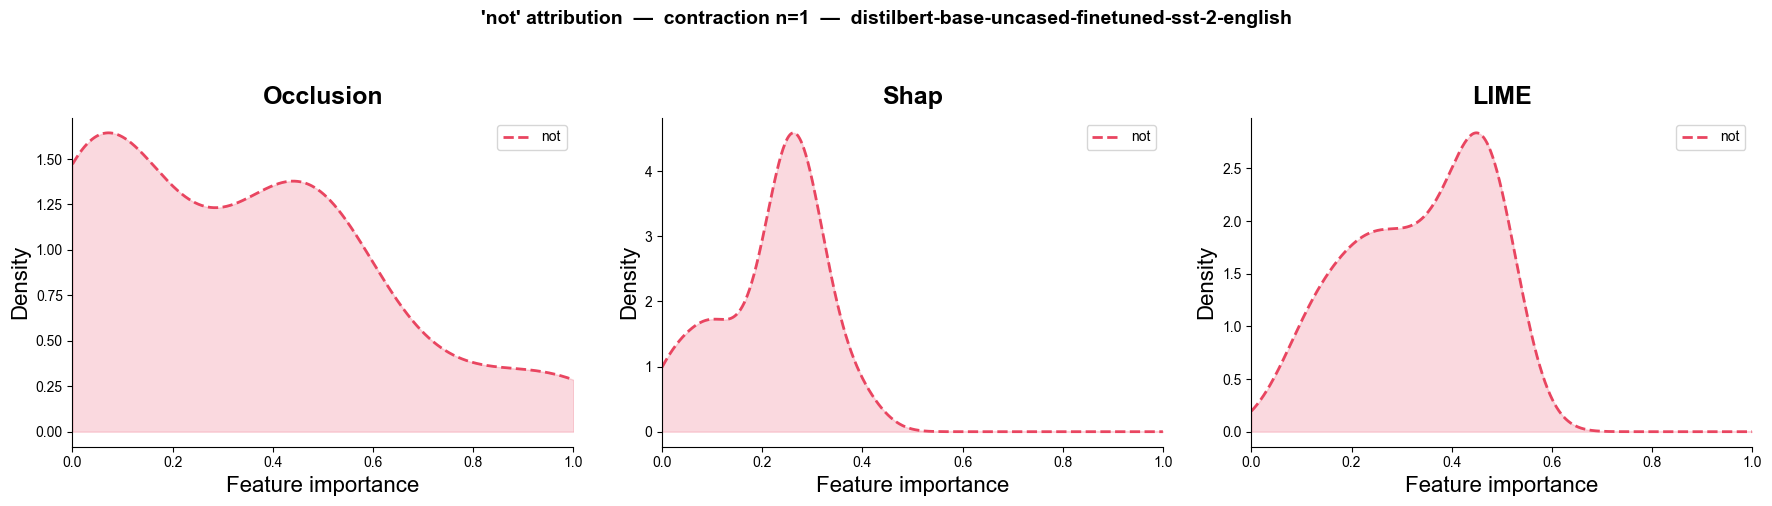

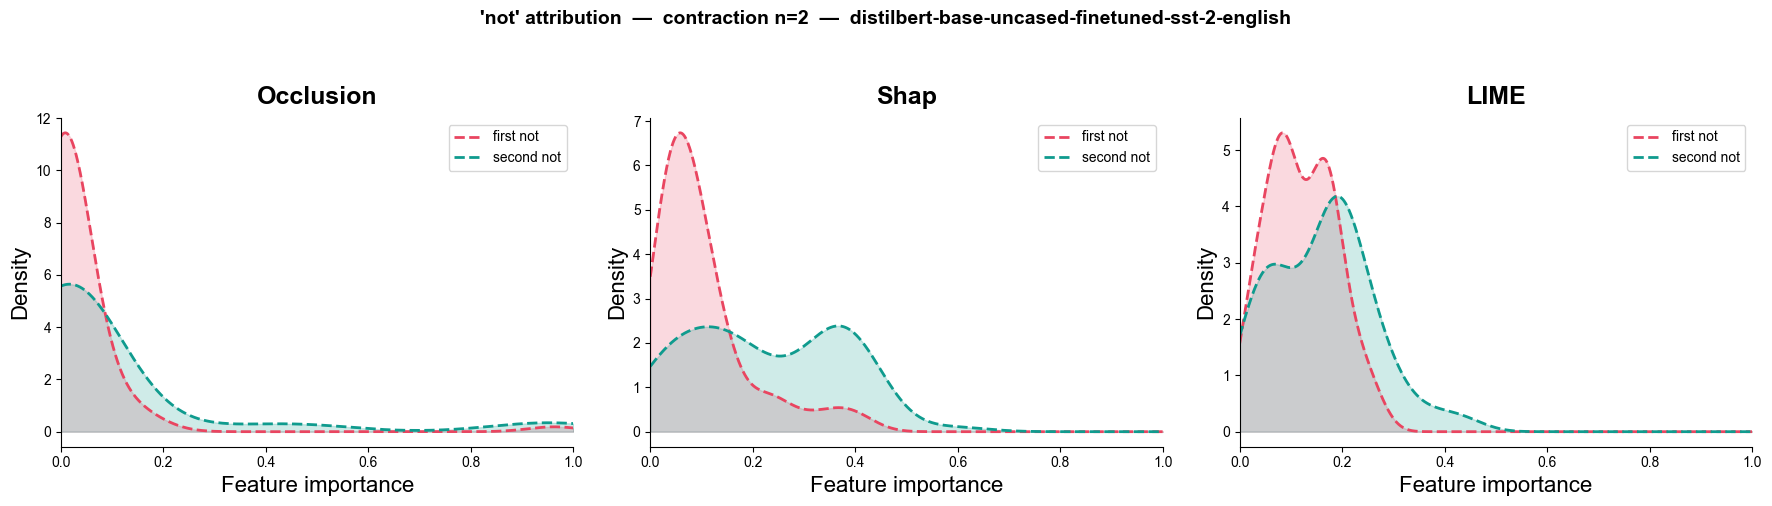

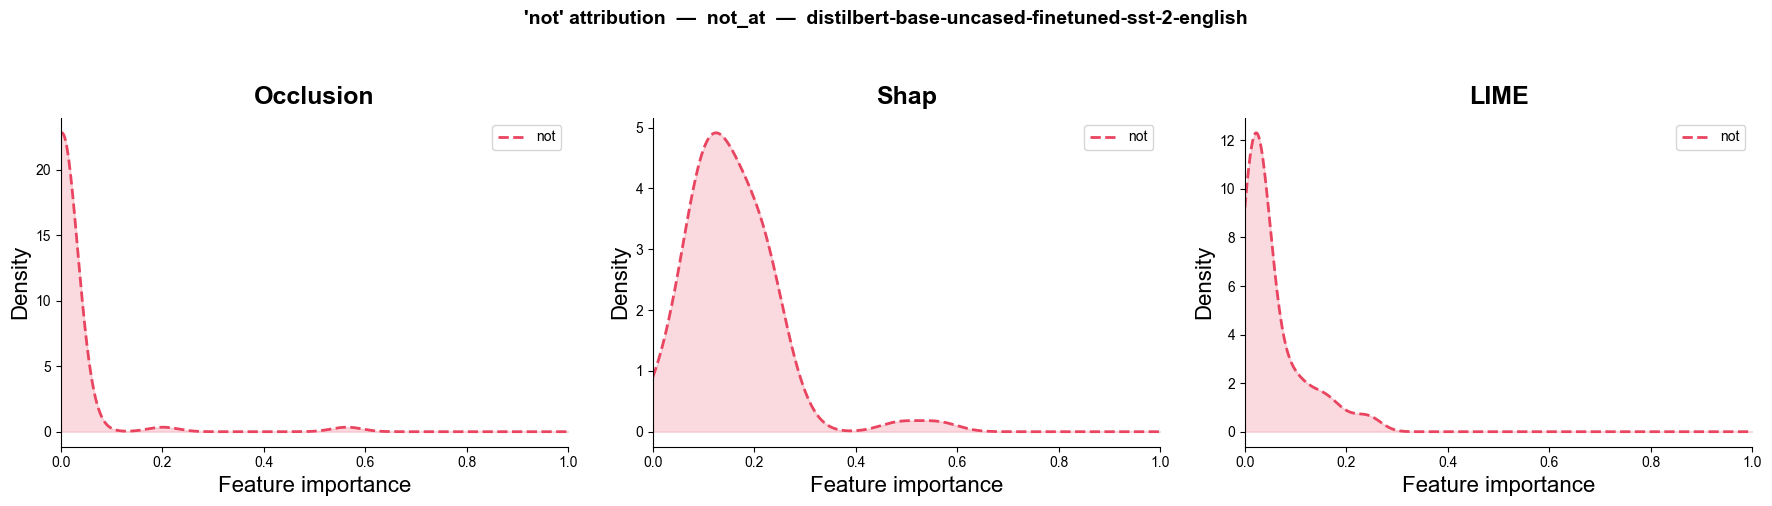

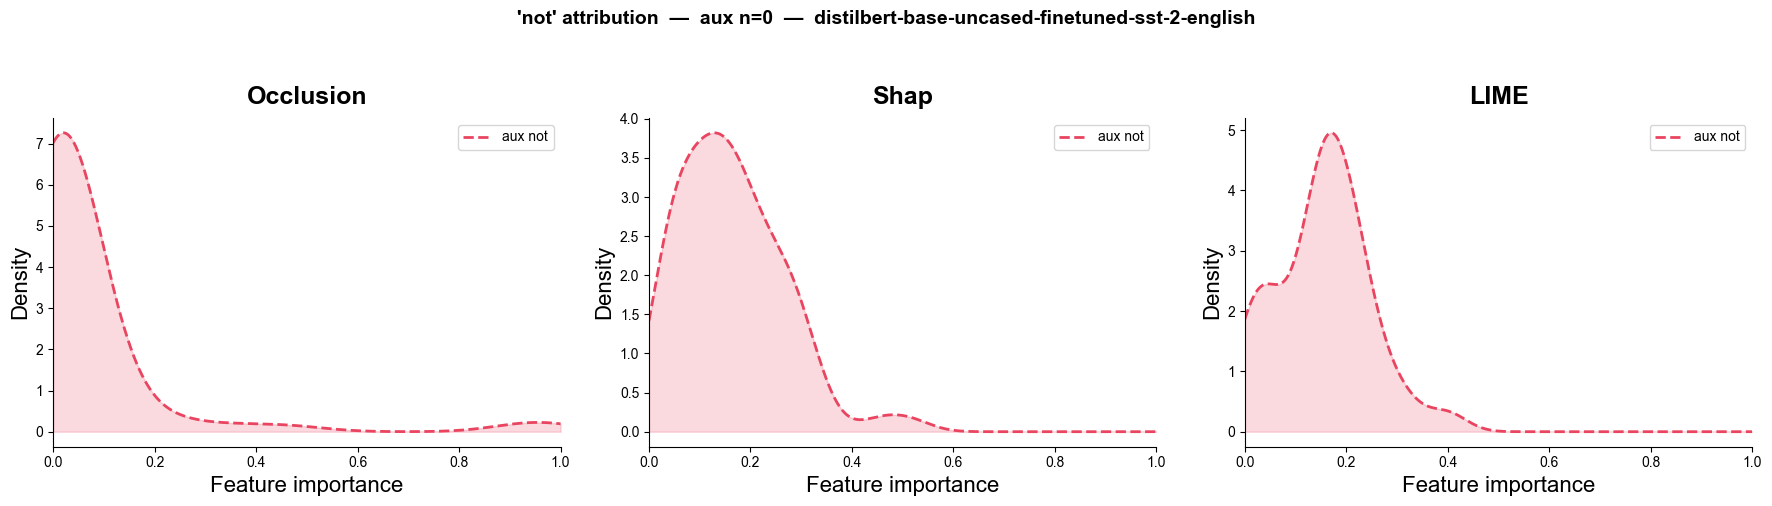

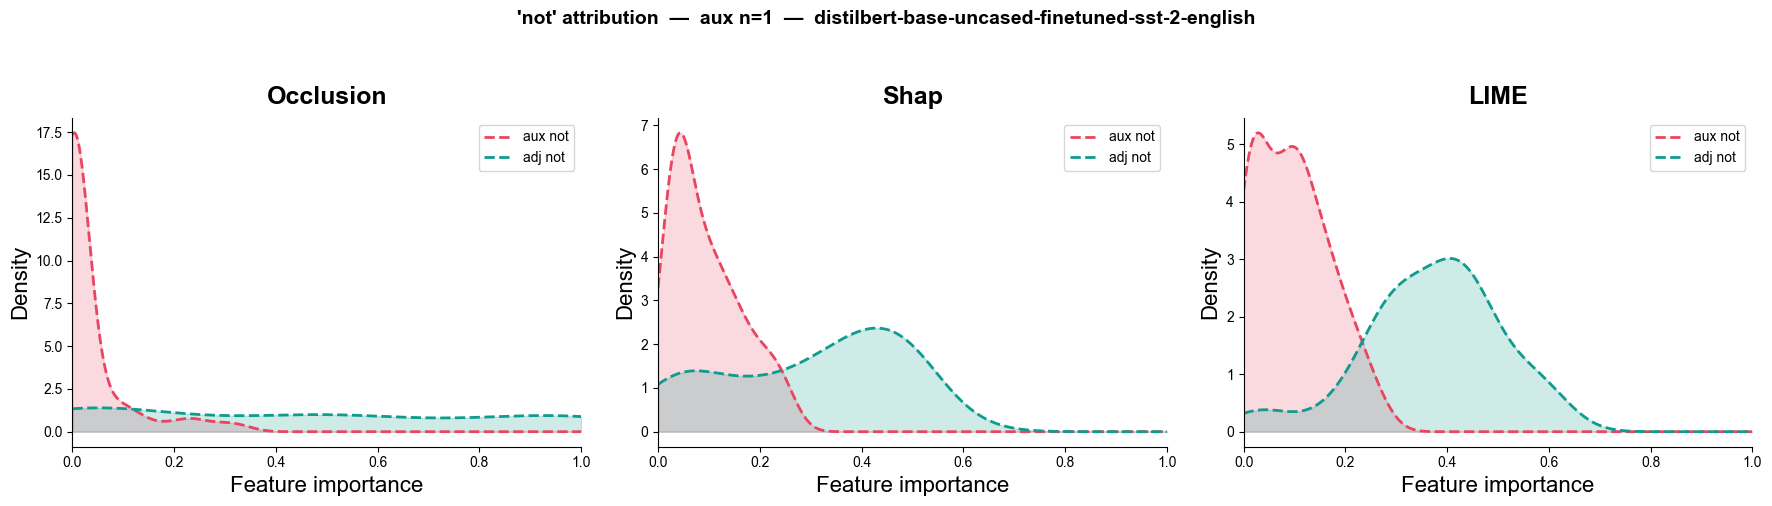

In [18]:
plot_not_attribution_normalized(MODELS["distilbert"])

## Roberta

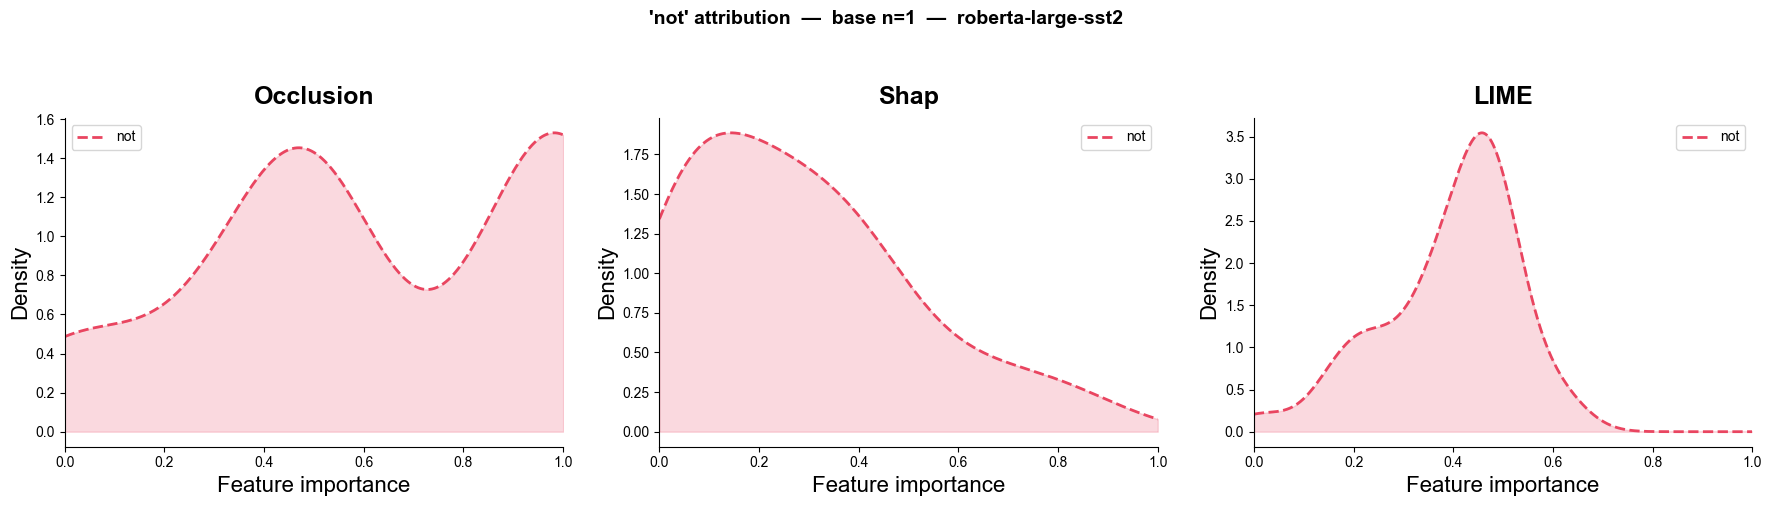

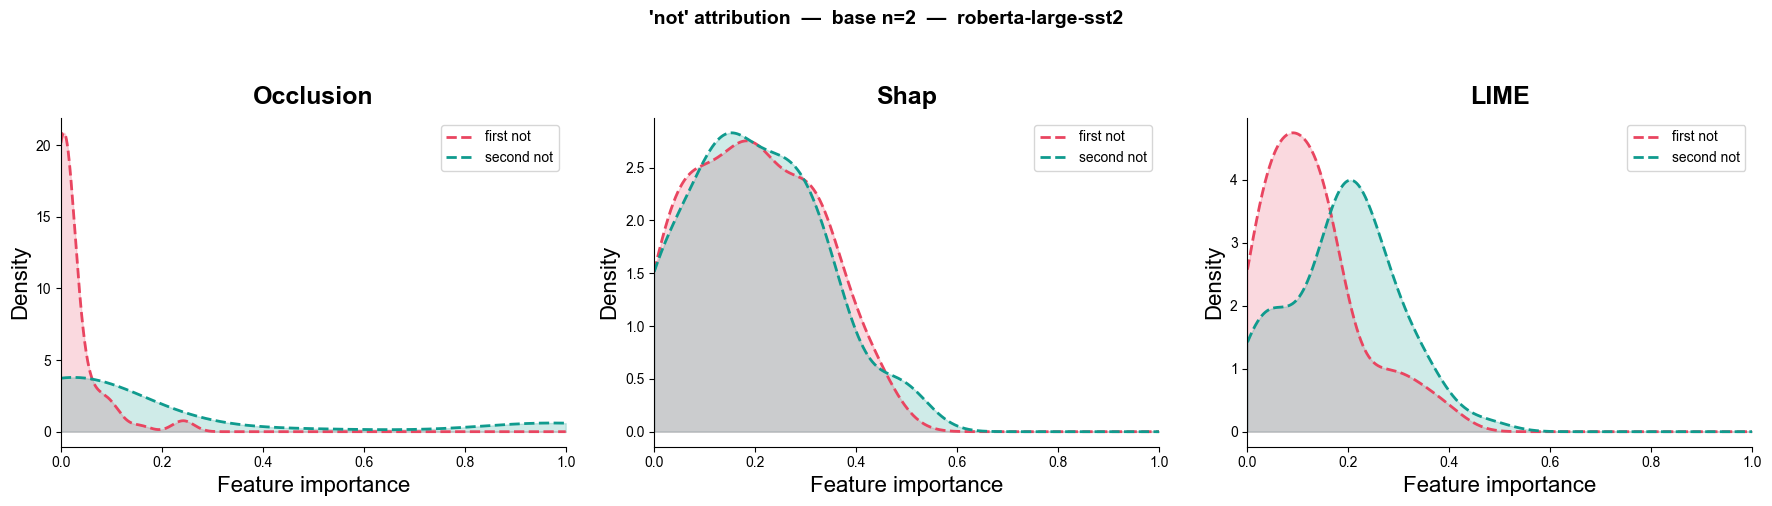

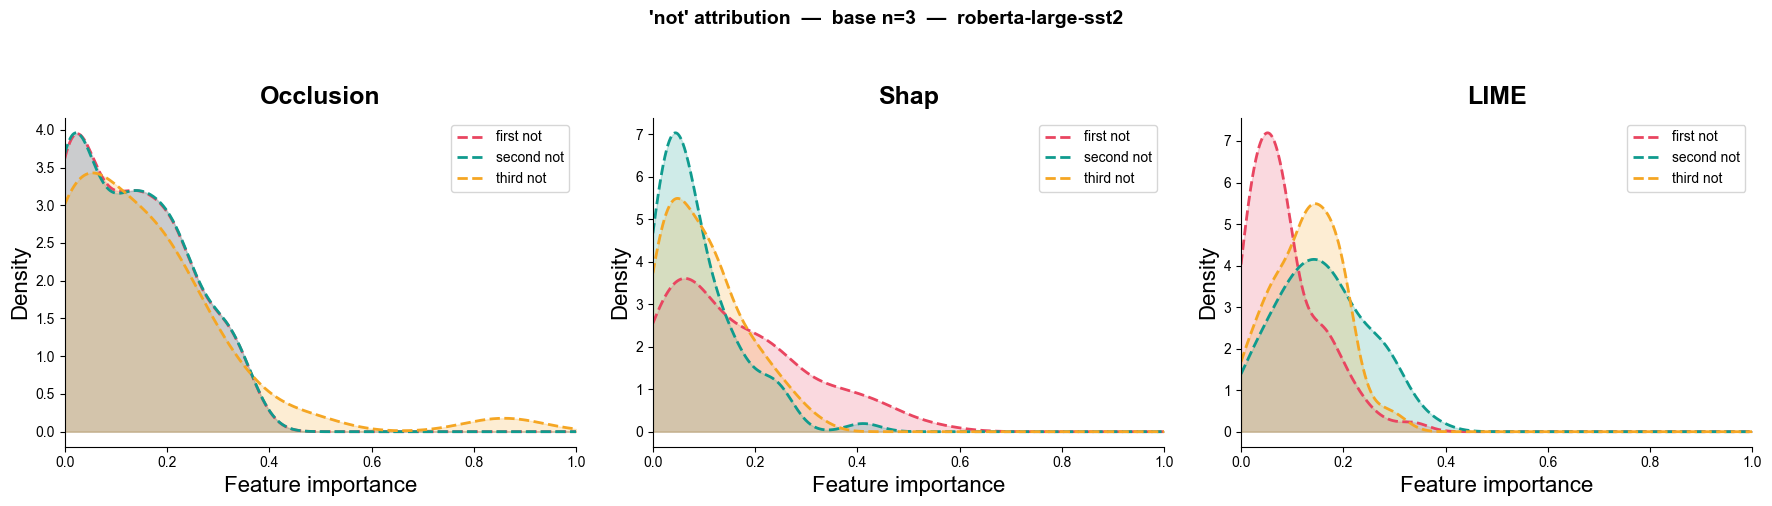

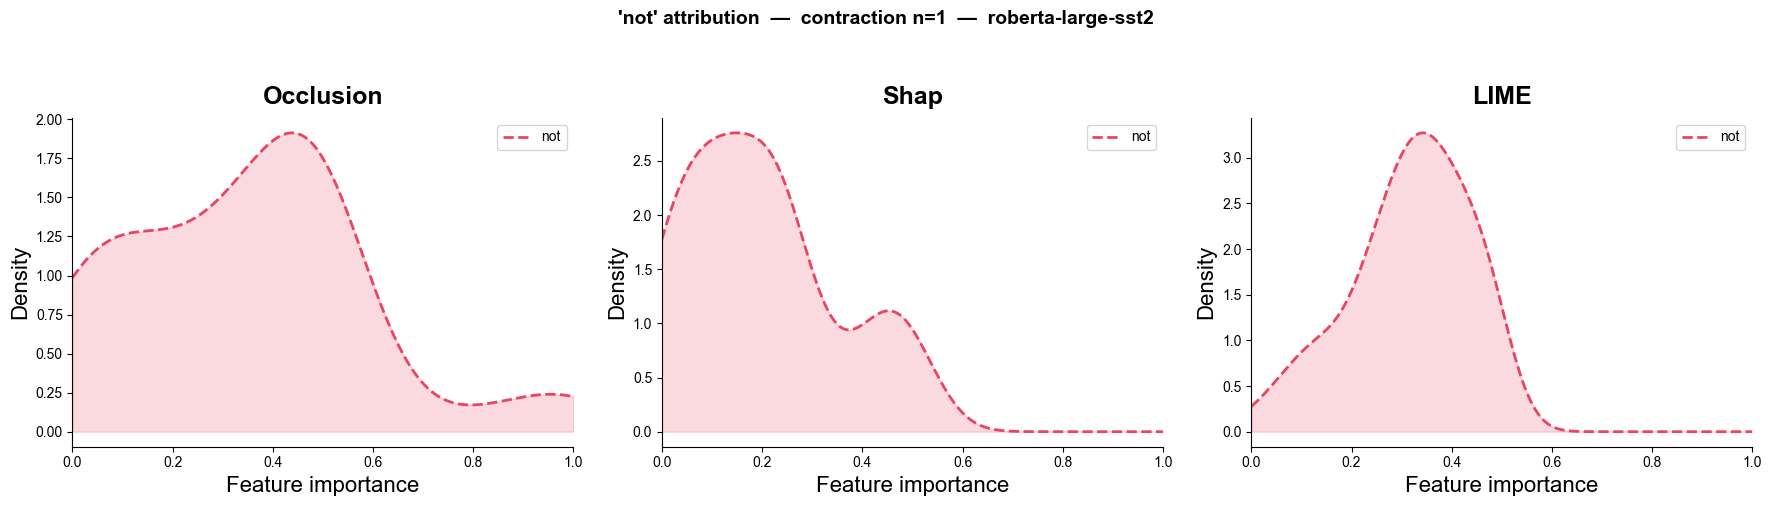

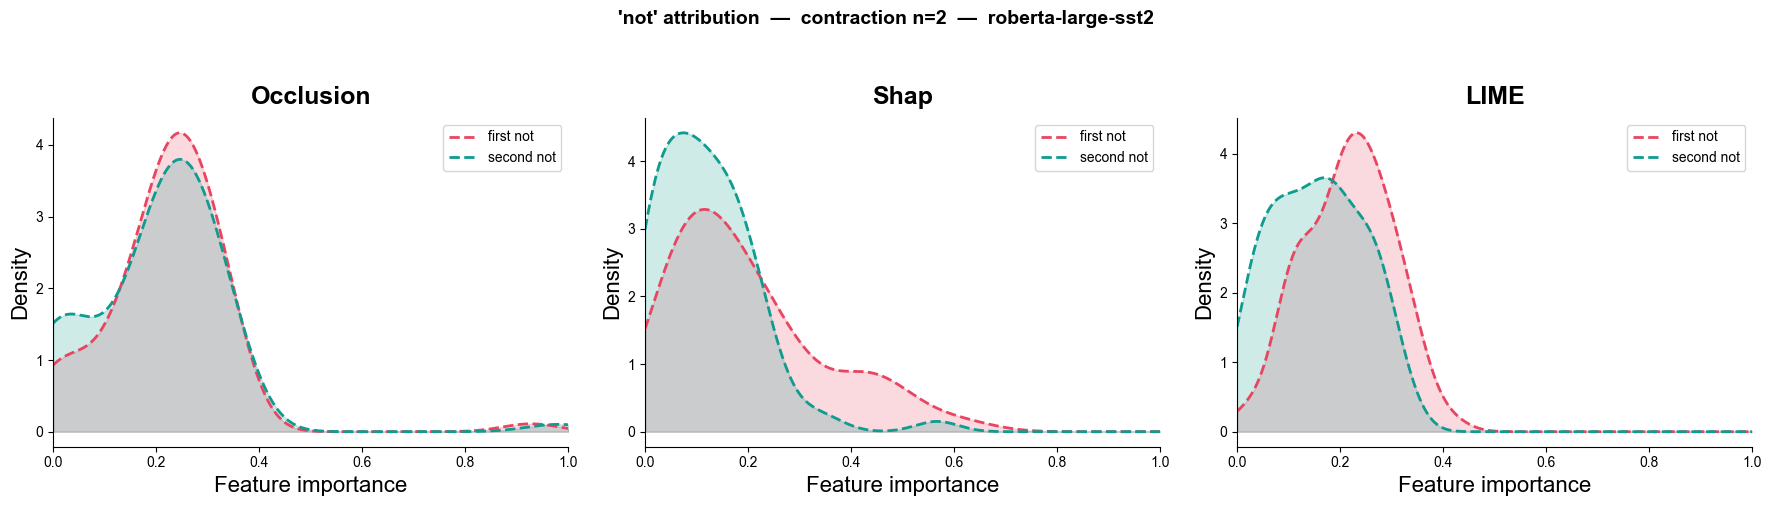

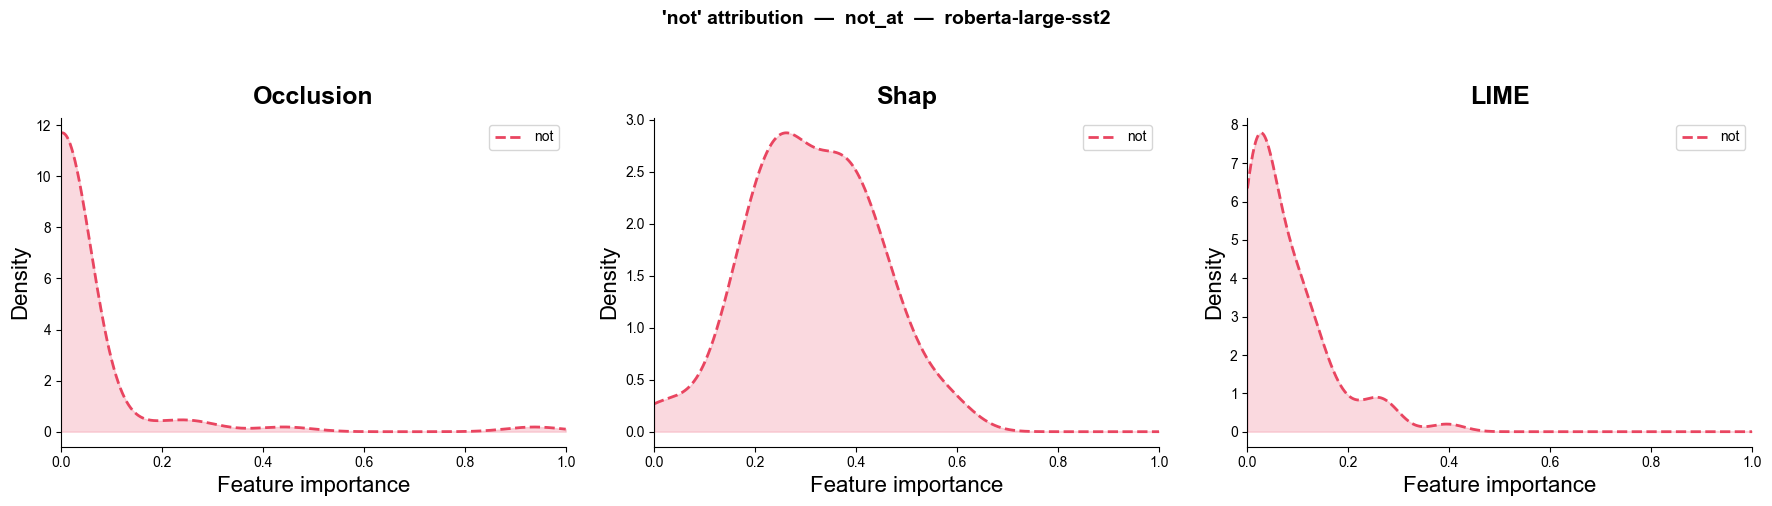

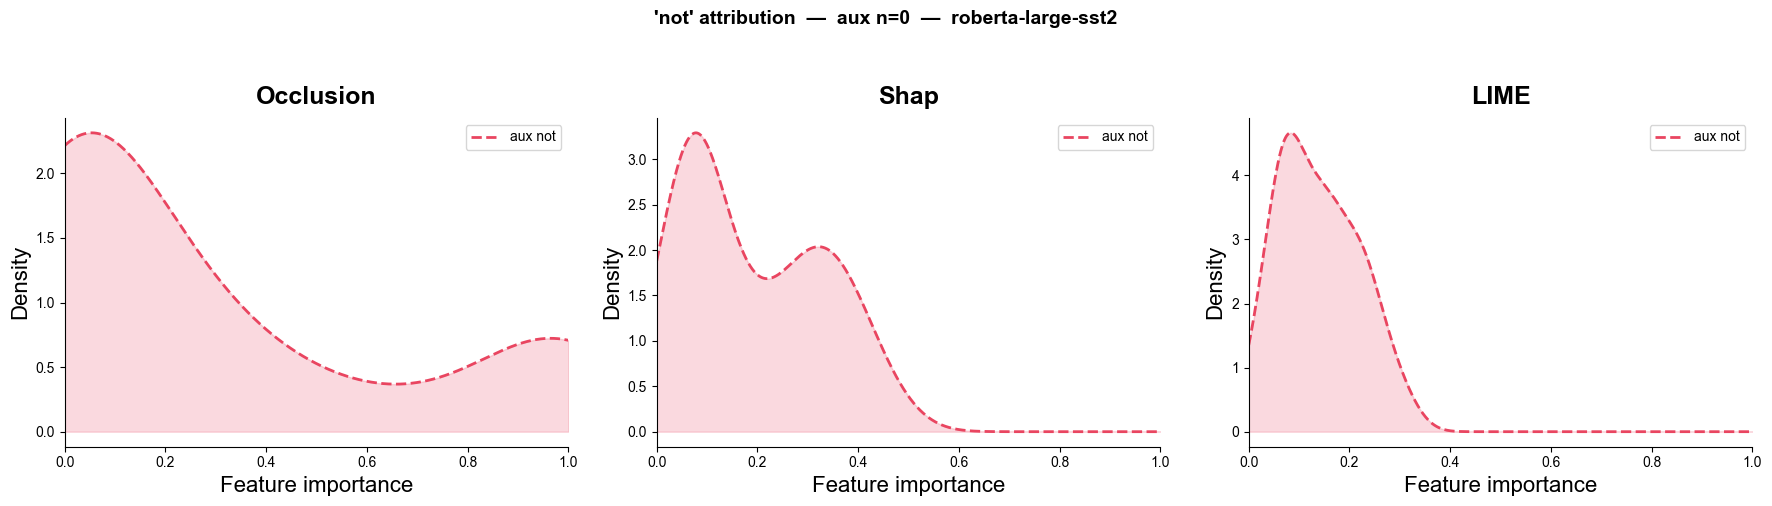

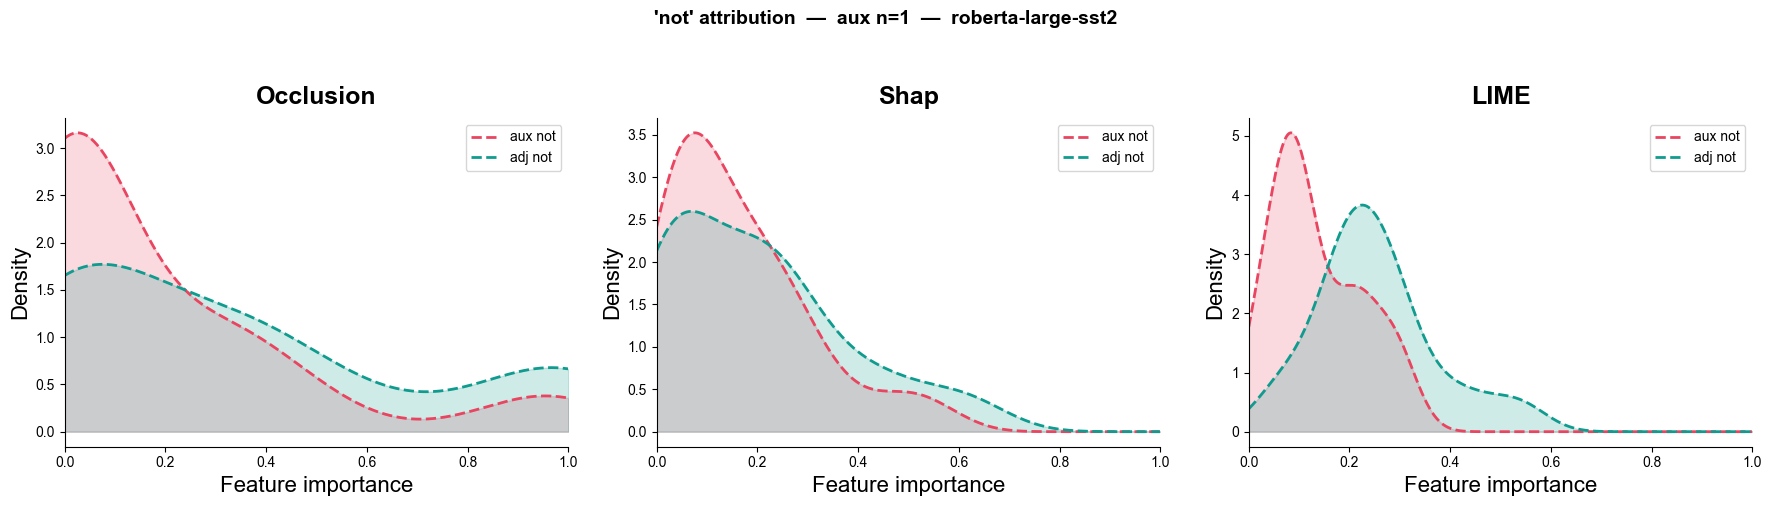

In [17]:
plot_not_attribution_normalized(MODELS["roberta"])

## Compute distance

In [12]:
df_metrics = compute_metrics_between_nots("siebert/sentiment-roberta-large-english")
df_metrics

['base n=1', 'base n=2', 'base n=3', 'contraction n=1', 'contraction n=2', 'not_at', 'aux n=0', 'aux n=1']


,comparison,config_a,config_b,pair,method,L1,K,KL
0,cross_config,contraction n=1,aux n=1,pos -2 vs pos -2,LIME,0.498594,0.399099,0.251065
1,cross_config,base n=1,aux n=1,pos -2 vs pos -2,LIME,0.890667,0.616236,0.524469
2,cross_config,base n=1,not_at,pos -2 vs pos -2,LIME,0.379114,0.318702,0.136494
3,cross_config,base n=1,contraction n=1,pos -2 vs pos -2,LIME,1.264054,0.774530,4.201085
4,within_config,aux n=1,aux n=1,aux not vs adj not,LIME,1.114886,0.715844,0.932185
5,within_config,contraction n=2,contraction n=2,first not vs second not,LIME,0.333413,0.285773,0.117399
6,within_config,base n=3,base n=3,second not vs third not,LIME,0.689438,0.512700,0.330754
7,within_config,base n=3,base n=3,first not vs third not,LIME,0.863525,0.603120,0.507067
8,within_config,base n=3,base n=3,first not vs second not,LIME,0.234281,0.209715,0.044127
9,within_config,base n=2,base n=2,first not vs second not,LIME,0.478149,0.385892,0.179166


In [13]:
df_metrics = compute_metrics_between_nots("distilbert-base-uncased-finetuned-sst-2-english")
df_metrics

['base n=1', 'base n=2', 'base n=3', 'contraction n=1', 'contraction n=2', 'not_at', 'aux n=0', 'aux n=1']


,comparison,config_a,config_b,pair,method,L1,K,KL
0,cross_config,contraction n=1,aux n=1,pos -2 vs pos -2,LIME,0.263103,0.232515,0.076476
1,cross_config,base n=1,aux n=1,pos -2 vs pos -2,LIME,1.022142,0.676436,1.560733
2,cross_config,base n=1,not_at,pos -2 vs pos -2,LIME,1.015123,0.673354,2.174107
3,cross_config,base n=1,contraction n=1,pos -2 vs pos -2,LIME,1.088725,0.704967,3.054379
4,within_config,aux n=1,aux n=1,aux not vs adj not,LIME,1.586602,0.884738,1.897757
5,within_config,contraction n=2,contraction n=2,first not vs second not,LIME,0.524635,0.415612,0.225126
6,within_config,base n=3,base n=3,second not vs third not,LIME,0.594170,0.458081,0.258026
7,within_config,base n=3,base n=3,first not vs third not,LIME,0.824715,0.583928,0.415233
8,within_config,base n=3,base n=3,first not vs second not,LIME,0.609777,0.467302,0.253085
9,within_config,base n=2,base n=2,first not vs second not,LIME,0.438534,0.359670,0.194798
